# CNN Fundamentals using PyTorch

### Import and verify

In [ ]:
import torch

print(torch.__version__)

2.11.0+cpu


### Image as Tensors

**1. The Digital Grid (Spatial Dimensions)**
*   **Concept:** A computer does not "see" shapes or lighting; it only reads discrete numerical values arranged in a rigid 2D grid. Each discrete point in this grid is a pixel (picture element).
*   **Mathematics:** If an image is $H$ pixels high and $W$ pixels wide, the spatial resolution is mathematically represented as a matrix $M \in \mathbb{R}^{H \times W}$.

**2. The Depth Dimension (Color Channels)**
*   **Concept:** To represent color, the computer stacks multiple spatial matrices on top of each other. These are called **Channels**.
    *   A grayscale image has 1 channel (representing intensity from black to white).
    *   A standard digital color image uses the RGB color model, meaning it is composed of 3 distinct channels: Red, Green, and Blue.
*   **Mathematics:** The complete color image is a Rank-3 Tensor $T \in \mathbb{R}^{C \times H \times W}$. A $256 \times 256$ pixel RGB image is mathematically a tensor of shape `(3, 256, 256)`.

**3. Pixel Value Storage (Data Types)**
*   **Concept:** In standard file formats (like JPEG or PNG), the value of a single color channel for a single pixel is stored as an 8-bit unsigned integer (`uint8`).
*   **Mathematics:** An 8-bit integer can hold $2^8 = 256$ discrete values. Therefore, the numerical domain of raw image data is strictly bounded: $x \in [0, 255]$.
    *   $0$ represents the absolute absence of that color (black).
    *   $255$ represents the maximum intensity of that color.

**4. The Mathematics of Image Normalization**
*   **The CS Problem:** Standard neural networks rely on gradient descent. If we feed a matrix containing values up to $255$ into a network initialized with tiny weights (e.g., $0.01$), the dot products will produce massive numbers. This causes gradients to destabilize (explode) during the backward pass, mathematically preventing the network from converging.
*   **The Solution (Min-Max Scaling):** We must compress the $0-255$ integer range into a floating-point range of $0.0$ to $1.0$.
    *   **Formula:** $x_{scaled} = \frac{x_{raw}}{255.0}$
*   **The Solution (Standardization/Z-Score Normalization):** To further optimize hardware computation, computer scientists go a step further. They calculate the statistical Mean ($\mu$) and Standard Deviation ($\sigma$) of the entire image dataset, and shift the tensor values so the data is centered around zero with a standard deviation of 1.
    *   **Formula:** $x_{norm} = \frac{x_{scaled} - \mu}{\sigma}$

**5. The GPU Batch Format (B, C, H, W)**
*   **Concept:** As we learned in the previous module, GPUs are designed for massive parallel throughput. We never send a single `(C, H, W)` image to the GPU. We stack $B$ number of images into a contiguous block of memory.
*   **Mathematics:** The final Rank-4 Tensor sent to the hardware is $T_{batch} \in \mathbb{R}^{B \times C \times H \times W}$.

In [ ]:
""" IMAGE LOADING, TRANSFORMATION AND EXECUTION PIPELINE """

import torch
import torchvision.transforms as transforms
import numpy as np
from PIL import Image

print(torch.__version__)
print(np.__version__)
print(Image.__version__)

2.11.0+cu128
2.0.2
11.3.0


In [ ]:
# Set the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Target Hardware: {device}")

Target Hardware: cuda


In [ ]:
# Simulating reading a raw image (.jpg) from SSD / HDD

# Generating a random 256x256 (H x W) image with random pixel values between 0 - 255
# Current shape in Height x Width x Channels and the type is 8 bit unsigned integer
raw_memory_block = np.random.randint(0, 256, size=(256, 256, 3), dtype=np.uint8)
raw_image = Image.fromarray(raw_memory_block)

print("INITIAL STATE (RAM)")
print(raw_memory_block[10:15, 10:15])
print(raw_image)
print("Data Type (raw memory block): ", type(raw_memory_block))
print("Data Type: ", type(raw_image))
print("Raw Shape (HWC): ", raw_memory_block.shape)

INITIAL STATE (RAM)
[[[ 82 153 114]
  [208  26 162]
  [126 178  12]
  [ 92 136  99]
  [ 26 205  47]]

 [[165 239  82]
  [119 245  80]
  [152 102 224]
  [ 17 161  32]
  [175   9 131]]

 [[226 250  96]
  [ 76 143 220]
  [112 101 111]
  [ 12 100 176]
  [138  57 214]]

 [[216  36 243]
  [123  35  33]
  [101 104 207]
  [ 89  77  87]
  [125  35  45]]

 [[228 110 168]
  [142 129  30]
  [ 80 121  26]
  [200 201 240]
  [ 90 244 103]]]
<PIL.Image.Image image mode=RGB size=256x256 at 0x79982674CD10>
Data Type (raw memory block):  <class 'numpy.ndarray'>
Data Type:  <class 'PIL.Image.Image'>
Raw Shape (HWC):  (256, 256, 3)


#### Image Transformation Pipeline Breakdown

The image pipeline sequentially converts a **raw PIL Image or NumPy array** into a **normalized PyTorch tensor** with a reshaped memory layout, making it ready for deep learning models.

##### 1. Input Data Format
* **Format**: A raw RGB image loaded via a library like PIL or NumPy.
* **Shape**: $H \times W \times C$ (Height, Width, Channels).
* **Data Range**: Integer values from $0$ to $255$.

##### 2. Step-by-Step Execution

###### 1. Convert to Tensor
* **Action**: `transforms.ToTensor()` processes the raw image.
* **Layout Shift**: Rearranges the dimensions from $H \times W \times C$ to $C \times H \times W$ (Channels, Height, Width) to match PyTorch expectations.
* **Value Scaling**: Scales all pixel values down from integers to a floating-point range of $[0.0, 1.0]$.

###### 2. Standardize Values
* **Action**: `transforms.Normalize()` applies a statistical shift to each color channel independently.
* **Formula**: It computes the new value for each pixel using the formula:
$$\text{Output} = \frac{\text{Pixel Value} - \text{Mean}}{\text{Std}}$$
* **Data Shift**: It shifts the pixel values from $[0.0, 1.0]$ to a range centered around zero (typically between roughly $-2.1$ and $2.6$), matching the distribution of the ImageNet dataset.

###### 3. Output Data Format
* **Format**: A `torch.Tensor` object ready for GPU processing.
* **Shape**: $C \times H \times W$ ($3$ channels $\times$ Height $\times$ Width).
* **Data Range**: Normalized floating-point numbers centered around $0.0$.

The raw image passes through structural rearrangement and mathematical scaling to produce an optimized, model-ready tensor.


In [ ]:
# Image transformation pipeline

# Standard deep learning vision pipeline
# Declaraing mathematical opeations the CPU will perform on the image before sending it to the GPU
# Input data format: Memory Layout (Shape) = HWC, Format = RGB, Data Range = 0 to 255 per pixel per layer.
image_pipeline = transforms.Compose([
    # First operation: trasnforms.ToTensor()
    # Convert the image into tensor
    # Changes the memory layout from HWC (256, 256, 3) to CHW (3, 256, 256)
    # Casts the uint8 integers to float32 and divides every pixel by 255.0
    transforms.ToTensor(),
    # Second operation: transforms.Normalize()
    # Execute the statistical shift
    # Using the mean and standard deviation numbers from ImageNet dataset (universal standard)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],    # Mean for R, G, B
                         std=[0.299, 0.244, 0.255]      # Standard Deviation for R, G, B
    )
])
# Output data format: torch.Tensor() ready for GPU, Memory Layout (Shape) = CHW, Data Range = Normalized floating-point numbers centered around 0.0

In [ ]:
# Exuting the image transformation pipeline and loading it onto the GPU

print("Executing Image Transformation Pipeline")

# Run the image through the image transform pipeline
processed_tensor = image_pipeline(raw_image)
print("Updated Data Type:", processed_tensor.dtype)
print("Updated Shape:", processed_tensor.shape)
print(f"Min Max Range of data: Min={processed_tensor.min():.2f}, Max={processed_tensor.max():.2f}")

# Construct image batch (video) for GPU loading
batch_tensor = processed_tensor.unsqueeze(0)
print(f"Batch Shape (B, C, H, W):", batch_tensor.shape)

# Load the batch to the GPU through PCIE
gpu_batch = batch_tensor.to(device)
print("Final State (VRAM)")
print("Device:", gpu_batch.device)

# The image is now in GPU VRAM and ready to servce for CNN training

Executing Image Transformation Pipeline
Updated Data Type: torch.float32
Updated Shape: torch.Size([3, 256, 256])
Min Max Range of data: Min=-1.87, Max=2.33
Batch Shape (B, C, H, W): torch.Size([1, 3, 256, 256])
Final State (VRAM)
Device: cuda:0


### Convolution

#### Convolution Operation (Edge Detection) in Image

**1. The Input Tensor (The Image)**
We load a small $6 \times 6$ pixel region of the road into RAM.
The left half is bright white (pixel value 10), and the right half is dark asphalt (pixel value 0).
<br><br>
$$
\text{Input } (I) =
\begin{bmatrix}
10 & 10 & 10 & 0 & 0 & 0 \\
10 & 10 & 10 & 0 & 0 & 0 \\
10 & 10 & 10 & 0 & 0 & 0 \\
10 & 10 & 10 & 0 & 0 & 0 \\
10 & 10 & 10 & 0 & 0 & 0 \\
10 & 10 & 10 & 0 & 0 & 0
\end{bmatrix}
$$
<br>
**2. The Learnable Weights (The Kernel)**
Instead of random numbers, let's assume our CNN has already "learned" the exact weights required to detect a vertical edge. This specific $3 \times 3$ matrix is known mathematically as the Prewitt vertical operator.
<br><br>
$$
\text{Kernel } (K) =
\begin{bmatrix}
 1 & 0 & -1 \\
 1 & 0 & -1 \\
 1 & 0 & -1
\end{bmatrix}
$$
<br>
**3. The Execution: Scanning a Flat Region**
The GPU places the $3 \times 3$ kernel over the top-left corner of the input image. This region is entirely bright white `(10)`.
The CPU/GPU computes the element-wise multiplication and sums the result (the dot product):
Using Convolution Formula:
<br>
$$S(i, j) = \sum_{m} \sum_{n} I(i + m, j + n) \cdot K(m, n)$$
<br>
- **The Goal:** We want to calculate a single number for our output Feature Map ($S$) at the specific 2D coordinate $(i, j)$.
- **The** $\Sigma \Sigma$ **(The 2D Loop):** The double Sigma is just a 2D nested `for` loop in computer science. It iterates over the height ($m$) and width ($n$) of your tiny $3 \times 3$ Kernel ($K$).
- $I(i + m, j + n)$ **(The Offset):** $I$ is your massive input image. $(i, j)$ is the current anchor point we are looking at. $+m$ and $+n$ act as spatial offsets. The math is saying: *"Lock onto coordinate* $(i,j)$ *in the main image. Now, read the small* $3 \times 3$ *grid of memory addresses directly surrounding it."*
- $\cdot K(m, n)$ **(The Dot Product):** We take the value extracted from the image and multiply it by the specific weight located at $(m, n)$ inside the Kernel. The $\Sigma$ commands us to add all 9 of these multiplication results together into one final number.
<br>
$$
\text{Patch} =
\begin{bmatrix}
10 & 10 & 10 \\
10 & 10 & 10 \\
10 & 10 & 10
\end{bmatrix}
*
\begin{bmatrix}
 1 & 0 & -1 \\
 1 & 0 & -1 \\
 1 & 0 & -1
\end{bmatrix}
$$
<br>
$$
\text{Calculation: } (10\times1 + 10\times0 + 10\times-1) \times 3 \text{ rows}
$$
<br>
$$
\text{Result: } (10 + 0 - 10) + (10 + 0 - 10) + (10 + 0 - 10) = \mathbf{0}
$$
<br>
*CS Conclusion:* The output is 0. The kernel mathematically proves there is no vertical edge in this specific patch of memory.

**4. The Execution: Hitting the Edge**
The GPU strides the kernel over to the middle of the image, where the 10s meet the 0s.
<br><br>
$$
\text{Patch} =
\begin{bmatrix}
10 & 10 & 0 \\
10 & 10 & 0 \\
10 & 10 & 0
\end{bmatrix}
*
\begin{bmatrix}
 1 & 0 & -1 \\
 1 & 0 & -1 \\
 1 & 0 & -1
\end{bmatrix}
$$
<br>
$$
\text{Calculation: } (10\times1 + 10\times0 + 0\times-1) \times 3 \text{ rows}
$$
<br>
$$
\text{Result: } (10 + 0 + 0) + (10 + 0 + 0) + (10 + 0 + 0) = \mathbf{30}
$$
<br>
*CS Conclusion:* The output is a massive positive number (30). The kernel has successfully "activated." This high numerical value tells the next layer of the neural network: *"I found a stark vertical boundary at this exact spatial coordinate."*

**5. The Output Feature Map**
After sliding across the entire $6 \times 6$ image (with a stride of 1 and no padding), the resulting Feature Map is a $4 \times 4$ tensor.

$$
\text{Feature Map } =
\begin{bmatrix}
0 & 30 & 30 & 0 \\
0 & 30 & 30 & 0 \\
0 & 30 & 30 & 0 \\
0 & 30 & 30 & 0
\end{bmatrix}
$$
<br>
The network has successfully transformed a grid of raw pixel intensities into a mathematical map of geometric features. If we configure a convolutional layer with 64 `out_channels`, the GPU runs 64 of these distinct filters simultaneously, extracting horizontal edges, diagonal lines, and color blobs all in one massive parallel operation.

In [ ]:
""" SIMULATING THE CONVOLUTION OPERATION """

import torch
import torch.nn as nn

In [ ]:
# Harware setup, sample data allocation then moving the sample data to GPU

# Set the device as GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Allocate a sample batch of images in VRAM
# Batch Size (No. of images) (B) = 32, RGB Channels (C) = 3, Height (H) = 64, Width (W) = 64
batch_size = 32
input_tensor = torch.randn(size=(batch_size, 3, 64, 64)).to(device)
print(f"Input tensor shape: {input_tensor.shape}")
print(f"Input tensor device: {input_tensor.device}")

cuda
Input tensor shape: torch.Size([32, 3, 64, 64])
Input tensor device: cuda:0


In [ ]:
# Defining a class for the Convolution operation and creating an object of it

class ConvOperation(nn.Module):
    def __init__(self, stride_jump):
        super().__init__()

        self.conv_layer = nn.Conv2d(
            in_channels=3,              # The depth of the input tensor (image color channels) (3 for R, G, B)
            out_channels=16,            # How many feature maps we want to generate to extract distinct viusal patterns from our RGB images.
            kernel_size=3,              # 3x3 sliding window (filter) (GPU will create 16 separate 3x3 kernels)
            stride=stride_jump,         # The window jumps certain pixel (eg: 1 pixel or 2 pixels) at a time to the right or down (if started form top left)
            padding=1                   # We add a 1 pixel border of 0s to preserve spatial dimentions
        )

        self.conv_layer = self.conv_layer.to(device)

    # The forward pass (prediction)
    def forward(self, input_tensor):
        output = self.conv_layer(input_tensor)
        return output

# Instantiate an object for the convolution operation with default random weights and stride jump rate of 1
conv_model = ConvOperation(1)
# Shape: [16, 3, 3, 3]
# 16 sets of kernels to produce 16 feature maps on convolution operation
# 3 kernels for each input channel (R, G, B)
# Each kernel has H=3, W=3
print(f"Allocated kernel weights shape: {conv_model.conv_layer.weight.shape}")
print(f"Peeking into a sample of the weights:\n{conv_model.conv_layer.weight[5:6, 1:2, :, :]}")

Allocated kernel weights shape: torch.Size([16, 3, 3, 3])
Peeking into a sample of the weights:
tensor([[[[-0.1101, -0.0068,  0.0830],
          [-0.0056, -0.1208, -0.0960],
          [ 0.1373, -0.1130, -0.1726]]]], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [ ]:
# Execution of the convolution operation using our input tensor and mathematical verification

# The forward pass (extracting the feature maps)
# The feature maps should of 64 x 64
output_tensor = conv_model(input_tensor)
# Shpae: [32, 16, 64, 64]
# 32 sets of feature maps for 32 images
# 16 feature maps in each set
# Each feature maps has H=64, W=64
print(output_tensor.shape)
print(output_tensor.device)

torch.Size([32, 16, 64, 64])
cuda:0


Convolution Output Shape Forumula (precalculating the Width of each output feature map):

$$W_{out} = \lfloor \frac{W_{in} - K + 2P}{S} \rfloor + 1$$
<br>
- $W_{in}$**:** Width of the input image.
- $W_{out}$**:** Width of the output feature map.
- $W_{in} + 2P$**:** This is the total physical memory footprint. If the input width is $5$ and Padding is $1$, we add $1$ column of zeros to the left and $1$ to the right. Total physical width is $5 + 2(1) = mathbf{7}$.
- **$- K$:** Why subtract the Kernel size? Because the Kernel cannot slide off the edge of the memory block. If you have a $3$-pixel wide kernel sliding across $7$ pixels, the very first placement consumes pixels index $0, 1, 2$. It cannot start at index $6$ because there is no data at index $7$ or $8$. We subtract $K$ to find the total *slidable distance*.
- **$/ S$:** We divide the slidable distance by the Stride. If Stride is $2$, we skip every other pixel, literally cutting the number of operations (and the output dimension) in half.
- **$+ 1$:** We must add $1$ at the very end to account for the very first valid placement of the kernel at index $(0,0)$ before any sliding movement actually occurred.

We use the same formula to calculate the height as well:
1.  **Vertical Calculation:** $H_{out} = \left\lfloor \frac{H_{in} - K_h + 2P_h}{S_h} \right\rfloor + 1$
2.  **Horizontal Calculation:** $W_{out} = \left\lfloor \frac{W_{in} - K_w + 2P_w}{S_w} \right\rfloor + 1$

In [ ]:
# Verification of the output tensor shape using the Convolution Output Shape formula

W_in = input_tensor.shape[3]                # Width of input images
K = conv_model.conv_layer.weight.shape[3]   # Kernel width
P = conv_model.conv_layer.padding[1]        # No. of padding
S = conv_model.conv_layer.stride[1]         # Stride jump length

print("For each image, each channel:")
print(f"Input width: {W_in}\nKernel width: {K}\nNo. of padding: {P}\nStride jump length: {S}")
W_out = int(((W_in - K + 2 * P) / S) + 1)
print(f"Width and potential height of the output feature map: {W_out}")

For each image, each channel:
Input width: 64
Kernel width: 3
No. of padding: 1
Stride jump length: 1
Width and potential height of the output feature map: 64


In [ ]:
# Altering the stride jump length to 2 to reduce memory usage

downsampler_model = ConvOperation(2)

# Executing the forward pass and extracting the feature maps
downsampler_output = downsampler_model(input_tensor)
print(downsampler_output.shape)
print(downsampler_output.device)

# Verification of the downsampler output tensor shape using the Convolution Output Shape formula

W_in1 = input_tensor.shape[3]                           # Width of input images
H_in1 = input_tensor.shape[2]                           # Height of input images
Kw1 = downsampler_model.conv_layer.weight.shape[3]      # Kernel width
Kh1 = downsampler_model.conv_layer.weight.shape[2]      # Kernal height
P1 = downsampler_model.conv_layer.padding[1]            # No. of padding
S1 = downsampler_model.conv_layer.stride[1]             # Stride jump length

print("For each image, each channel:")
print(f"Input width: {W_in1}\nInput height: {H_in1}\nKernel width: {Kw1}\nKernel Height: {Kh1}\nNo. of padding: {P1}\nStride jump length: {S1}")
W_out1 = int(((W_in1 - Kw1 + 2 * P1) / S1) + 1)
H_out1 = int(((H_in1 - Kh1 + 2 * P1) / S1) + 1)
print(f"Width of the output feature map: {W_out1}")
print(f"Height of the output feature map: {H_out1}")

# Step by step calculation of the Convolution Output Shape Formula
# W_out = floor((64 - 3 + 2) / 2) + 1
# W_out = floor(63 / 2) + 1
# W_out = floor(31.5) + 1
# W_out = 31 + 1 = 32

torch.Size([32, 16, 32, 32])
cuda:0
For each image, each channel:
Input width: 64
Input height: 64
Kernel width: 3
Kernel Height: 3
No. of padding: 1
Stride jump length: 2
Width of the output feature map: 32
Height of the output feature map: 32


### Pooling & Hierarchies

**1. The Pooling Operation (Non-Learnable Downsampling)**
*   **Concept:** Pooling uses a sliding window over the **Feature map** exactly like Convolution. However, instead of computing a dot product with learnable weights, it executes a fixed, non-learnable mathematical reduction operator and outputs a separate tensor.
*   **Max Pooling:** The most common variant. As the window slides, it simply outputs the maximum numerical value found within that spatial window.
*   **Average (Mean) Pooling:** Computes the mathematical mean of the values in the window.

**2. The Mathematics of Max Pooling**
*   **The Algorithm:** Given a feature map $F$ and a $2 \times 2$ pooling window $W$, the calculation for the output region is: $P_{out} = \max_{(i,j) \in W} F(i, j)$.
*   **Stride and Overlap:** In pooling, the Stride ($S$) is traditionally set to equal the Kernel size ($K$). If $K=2$, then $S=2$. This means the windows *do not overlap*.
*   **Spatial Reduction:** Using the Master Formula $W_{out} = \lfloor \frac{W_{in} - K}{S} \rfloor + 1$:
    *   If $W_{in} = 64$, $K = 2$, $S = 2$.
    *   $W_{out} = \lfloor \frac{64 - 2}{2} \rfloor + 1 = 31 + 1 = 32$.
    *   A $2 \times 2$ Max Pool with a Stride of 2 mathematically cuts the spatial height and width exactly in half, discarding 75% of the total tensor volume in a single operation.

#### Demo of Pooling
Let's look at a strict mathematical scenario demonstrating exactly how Max Pooling solves the "Spatial Hyper-Sensitivity" problem. We call this mathematical property **Translation Invariance**.

**The Scenario: The Jittering Camera**
Imagine our self-driving car's camera is vibrating slightly. We pass two consecutive frames through our Convolutional layer. The Conv layer successfully detects a specific feature (like a stop sign's edge) and outputs a high activation number (let's use `9`).

Because the camera vibrated, the spatial location of the `9` shifts by one pixel in memory between Frame 1 and Frame 2.

**3. Frame 1 Feature Map (Before Pooling)**
The edge is detected in the absolute top-left memory address `(0, 0)`.

$$
\text{Feature Map of Frame 1} =
\begin{bmatrix}
\mathbf{9} & 1 & 0 & 2 \\
3 & 4 & 1 & 0 \\
0 & 2 & 5 & 1 \\
1 & 0 & 2 & 3
\end{bmatrix}
$$

**4. Frame 2 Feature Map (Before Pooling - The Shift)**
The camera vibrates. The exact same edge is detected, but its mathematical coordinate has shifted diagonally to `(1, 1)`. To a rigid matrix multiplication layer, this is a completely different input array.

$$
\text{Feature Map of Frame 2} =
\begin{bmatrix}
1 & 3 & 0 & 2 \\
4 & \mathbf{9} & 1 & 0 \\
0 & 2 & 5 & 1 \\
1 & 0 & 2 & 3
\end{bmatrix}
$$

**3. The Max Pooling Execution (Stride = 2, Kernel = 2)**
The GPU allocates a new, smaller tensor. It divides the $4 \times 4$ Feature Map into four distinct $2 \times 2$ quadrants and extracts only the maximum value from each.

**Processing Frame 1:**
*   Top-Left Quadrant: $\max(9, 1, 3, 4) = \mathbf{9}$
*   Top-Right Quadrant: $\max(0, 2, 1, 0) = \mathbf{2}$
*   Bottom-Left Quadrant: $\max(0, 2, 1, 0) = \mathbf{2}$
*   Bottom-Right Quadrant: $\max(5, 1, 2, 3) = \mathbf{5}$

$$
\text{Pooled Output 1} =
\begin{bmatrix}
\mathbf{9} & 2 \\
2 & 5
\end{bmatrix}
$$

**Processing Frame 2:**
*   Top-Left Quadrant: $\max(1, 3, 4, 9) = \mathbf{9}$
*   Top-Right Quadrant: $\max(0, 2, 1, 0) = \mathbf{2}$
*   Bottom-Left Quadrant: $\max(0, 2, 1, 0) = \mathbf{2}$
*   Bottom-Right Quadrant: $\max(5, 1, 2, 3) = \mathbf{5}$

$$
\text{Pooled Output 2} =
\begin{bmatrix}
\mathbf{9} & 2 \\
2 & 5
\end{bmatrix}
$$

##### The Conclusion
Look at the two output matrices. **They are mathematically identical.**

Even though the raw data moved to different memory addresses in the upstream tensors, the Pooling layer aggressively filtered the data, absorbing the spatial shift.

The next Convolutional layer deeper in the network will receive the exact same `2x2` input tensor in both scenarios. The network's mathematical behavior remains perfectly stable. It learned that the feature *exists in the top-left region*, without overfitting to the exact pixel coordinate.

Furthermore, any feature map passing through this operation drops 75% of its memory footprint (from 16 numbers down to 4), allowing the GPU to process drastically deeper architectural hierarchies without running out of VRAM.

In [ ]:
""" SIMULATING THE POOLING OPERATION """

import torch
import torch.nn as nn

In [ ]:
# GPU setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# Frames setup for the simulation

# Feature map of frame 1 with single channel
f_map_1 = torch.tensor([[[
    [9.0, 1.0, 0.0, 2.0],
    [3.0, 4.0, 1.0, 0.0],
    [0.0, 2.0, 5.0, 1.0],
    [1.0, 0.0, 2.0, 3.0]
]]]).to(device)

# Feature map of frame 2 with single channel (the 9 shifted diagonally in this frame)
f_map_2 = torch.tensor([[[
    [1.0, 3.0, 0.0, 2.0],
    [4.0, 9.0, 1.0, 0.0],
    [0.0, 2.0, 5.0, 1.0],
    [1.0, 0.0, 2.0, 3.0]
]]]).to(device)

print(f"Feature map 1:\n{f_map_1.squeeze()}\n")
print(f"Feature map 2:\n{f_map_2.squeeze()}\n")
print(f"Shape of Feature map 1 (B, C, H, W): {f_map_1.shape}")
print(f"Shape of Feature map 2 (B, C, H, W): {f_map_2.shape}")

Feature map 1:
tensor([[9., 1., 0., 2.],
        [3., 4., 1., 0.],
        [0., 2., 5., 1.],
        [1., 0., 2., 3.]], device='cuda:0')

Feature map 2:
tensor([[1., 3., 0., 2.],
        [4., 9., 1., 0.],
        [0., 2., 5., 1.],
        [1., 0., 2., 3.]], device='cuda:0')

Shape of Feature map 1 (B, C, H, W): torch.Size([1, 1, 4, 4])
Shape of Feature map 2 (B, C, H, W): torch.Size([1, 1, 4, 4])


In [ ]:
# The pooling layer (non learnable)

# Creating a pooling layer with 2x2 window and stride jump of 2
# Using the formula to calculate the width and height of the output tensor
# This object will automatically allocate memory of size calculated using that output formula
# W_out = floor((W_in - K) / S) + 1
# W_out: Output width, W_in = Input width (feature map), K = kernel width, S = Stride jump length
pooling_layer = nn.MaxPool2d(kernel_size=2, stride=2).to(device)

In [ ]:
# Execute forward pass on both the feature maps of the frames we defined above
output_1 = pooling_layer(f_map_1)
output_2 = pooling_layer(f_map_2)

print(f"Output 1 tensor shape: {output_1.shape}")
print(f"Output 1 tensor data:\n{output_1.squeeze()}\n")
print(f"Output 2 tensor shape: {output_2.shape}")
print(f"Output 2 tensor data:\n{output_2.squeeze()}")

# It it noticible that the output tensors are max pooled because both the output tensors are same unlike the input tensors
# It solved the Spatial hypersensitivity where a formula is too rigid and can break with a samll change
# Like the 9 in our example feature maps, moved to (1, 1) from (0, 0). In rigid matrix multiplication layer this is different
# We solve this using pooling that makes the operation translation invariant (different input but same output)
# It makes the output (input for the next layer) tensor smaller as well saving GPU space

Output 1 tensor shape: torch.Size([1, 1, 2, 2])
Output 1 tensor data:
tensor([[9., 2.],
        [2., 5.]], device='cuda:0')

Output 2 tensor shape: torch.Size([1, 1, 2, 2])
Output 2 tensor data:
tensor([[9., 2.],
        [2., 5.]], device='cuda:0')


In [ ]:
# FEW QUESTIONS TO ASK
# 1. Can you explain with detailed steps of how the autograd engine works for CNN? Show me the real thing.
# 2. What does shared parameter mean in CNN?
# 3. If doing convolution -> pool -> convolution -> pool multiple times and by layer 5 the feature map becomes 1 x 1, How does it even have the data for each and every feature in the image (eg. an edge, a corner or like a face)?

### Tracing a Complete Basic CNN Cycle
Let's define the 3 layers and the initial values in VRAM.
*(Note: To keep the math clean and traceable, we will omit the bias $+b$ and focus entirely on the weight matrices, which are the core of the learning process).*

**1. The Input Image ($X$):** A $3 \times 3$ grayscale image (1 channel).
$$ X = \begin{bmatrix} 1 & 2 & 1 \\ 0 & 1 & 2 \\ 2 & 0 & 1 \end{bmatrix} $$

**2. Layer 1: Convolutional Layer ($L_1$)**
*   **Kernel ($W_1$):** A $2 \times 2$ weight matrix.
*   **Hyperparameters:** Stride = 1, Padding = 0.
$$ W_1 = \begin{bmatrix} 1 & 0 \\ -1 & 1 \end{bmatrix} $$

**3. Layer 2: Max Pooling Layer ($L_2$)**
*   **Hyperparameters:** $2 \times 2$ window, Stride = 2. (Compresses the feature map).

**4. Layer 3: Linear Layer ($L_3$)**
*   **Weight ($W_2$):** A single scalar weight (a $1 \times 1$ matrix) connecting the pooled feature to the final prediction. Let's initialize it to `2.0`.
*   **Target ($y$):** The ground truth label we want the network to predict is `10.0`.
*   **Learning Rate ($\alpha$):** `0.1`.

<br>

#### PHASE 1: THE FORWARD PASS (Building the DAG)

The Forward Pass is where data flows left-to-right. We execute the math and store the intermediate Feature Maps in VRAM because the Autograd engine needs them later.

##### Step 1.1: Layer 1 (Convolution Execution)
*   **The "How":** We slide the $2 \times 2$ Kernel ($W_1$) over the $3 \times 3$ Input Image ($X$). At each step, we perform an element-wise multiplication and sum the result (a dot product).
*   **The Math (Cross-Correlation):**
    *   **Top-Left Window:** $\begin{bmatrix} 1 & 2 \\ 0 & 1 \end{bmatrix} * \begin{bmatrix} 1 & 0 \\ -1 & 1 \end{bmatrix} = (1)(1) + (2)(0) + (0)(-1) + (1)(1) = 1 + 0 + 0 + 1 = \mathbf{2}$
    *   **Top-Right Window:** $\begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix} * \begin{bmatrix} 1 & 0 \\ -1 & 1 \end{bmatrix} = (2)(1) + (1)(0) + (1)(-1) + (2)(1) = 2 + 0 - 1 + 2 = \mathbf{3}$
    *   **Bottom-Left Window:** $\begin{bmatrix} 0 & 1 \\ 2 & 0 \end{bmatrix} * \begin{bmatrix} 1 & 0 \\ -1 & 1 \end{bmatrix} = (0)(1) + (1)(0) + (2)(-1) + (0)(1) = 0 + 0 - 2 + 0 = \mathbf{-2}$
    *   **Bottom-Right Window:** $\begin{bmatrix} 1 & 2 \\ 0 & 1 \end{bmatrix} * \begin{bmatrix} 1 & 0 \\ -1 & 1 \end{bmatrix} = (1)(1) + (2)(0) + (0)(-1) + (1)(1) = 1 + 0 + 0 + 1 = \mathbf{2}$

*   **The Output (Feature Map 1):** We allocate a $2 \times 2$ tensor in RAM. Let's call it $F_1$.
$$ F_1 = \begin{bmatrix} 2 & 3 \\ -2 & 2 \end{bmatrix} $$

##### Step 1.2: Layer 2 (Max Pooling Execution)
*   **The "How":** We apply a $2 \times 2$ Max Pool to Feature Map 1 ($F_1$). Because the feature map is $2 \times 2$, this operation covers the entire map in a single step.
*   **The Math:** $\max(2, 3, -2, 2) = \mathbf{3}$
*   **The "Why" (The Argmax Cache):** During the forward pass, PyTorch doesn't just output the number `3`. It silently caches the *exact spatial index* where that `3` came from. Looking at $F_1$, the `3` was at the top-right corner, coordinate `(0, 1)`. The Autograd engine caches this coordinate so it knows exactly where to route the gradients later.
*   **The Output (Pooled Map):** We allocate a $1 \times 1$ tensor in RAM. Let's call it $P_1$.
$$ P_1 = \begin{bmatrix} 3 \end{bmatrix} $$

##### Step 1.3: Layer 3 (Linear / Fully Connected Execution)
*   **The "How":** We take the extracted pooled feature ($P_1$) and multiply it by our final Linear Weight ($W_2$) to get our prediction ($\hat{y}$).
*   **The Math:** $\hat{y} = P_1 \times W_2 = 3 \times 2.0 = \mathbf{6.0}$
*   **The Output (Prediction):** Our network predicts the value `6.0`.

##### Step 1.4: The Loss Calculation (The Final DAG Node)
*   **The "Why":** We need a single scalar number representing the mathematical error. We will use the standard **Mean Squared Error (MSE)**. To make the calculus derivative cleaner, computer scientists often multiply it by $\frac{1}{2}$. Formula: $L = \frac{1}{2}(\hat{y} - y)^2$
*   **The Math:**
    $$ L = \frac{1}{2}(6.0 - 10.0)^2 $$
    $$ L = \frac{1}{2}(-4.0)^2 $$
    $$ L = \frac{1}{2}(16.0) = \mathbf{8.0} $$
*   **The State of Memory:** We have a scalar `loss = 8.0`. The Forward Pass is complete. The DAG is fully built in RAM, pointing backward from $L \to \hat{y} \to P_1 \to F_1 \to X$.

<br>

#### PHASE 2: THE BACKWARD PASS (The Autograd Engine)

We currently have a `Loss` of `8.0`. We want to reduce it to `0.0`. To do this, we must traverse the DAG from right to left, using the Chain Rule to calculate how every weight contributed to that `8.0`.

**The Terminology:** As we move backward, the gradient calculated from the *subsequent* layer is passed backward to the *preceding* layer. We call this the **Upstream Gradient**. It acts as the mathematical error signal.

*(Note: We will use a Learning Rate of $\alpha = 0.01$ for this exercise to ensure we take a smooth step down the error surface without violently overshooting the target).*

##### Step 2.1: The Loss Derivative (The Starting Signal)
*   **The "Why":** We need to know the slope of the error at our exact prediction ($\hat{y} = 6.0$) relative to the target ($y = 10.0$).
*   **The Math:** The derivative of $L = \frac{1}{2}(\hat{y} - y)^2$ with respect to $\hat{y}$ is:
    $$ \frac{\partial L}{\partial \hat{y}} = (\hat{y} - y) = 6.0 - 10.0 = \mathbf{-4.0} $$
*   **The CS Meaning:** The negative sign tells the network: *"To reduce the error, you must increase the value of the prediction."* This `-4.0` is the very first **Upstream Gradient**, handed backward to Layer 3.

##### Step 2.2: Layer 3 Backward Pass (Linear Layer)
*   **The "Why":** Layer 3 has the equation $\hat{y} = P_1 \times W_2$. To satisfy the Chain Rule, the Autograd engine must calculate *two* distinct gradients here:
    1.  $\frac{\partial L}{\partial W_2}$: To know how to update the Linear Weight.
    2.  $\frac{\partial L}{\partial P_1}$: To pass the error signal backward to Layer 2.
*   **The Math (Gradient for the Weight):**
    $$ \frac{\partial L}{\partial W_2} = \text{Upstream Gradient} \times \text{Local Derivative (which is } P_1) $$
    $$ dW_2 = -4.0 \times 3.0 = \mathbf{-12.0} $$
    *(This is stored in VRAM as `W2.grad`)*
*   **The Math (Gradient for the Input):**
    $$ \frac{\partial L}{\partial P_1} = \text{Upstream Gradient} \times \text{Local Derivative (which is } W_2) $$
    $$ dP_1 = -4.0 \times 2.0 = \mathbf{-8.0} $$
*   **The State of Memory:** We hand this new Upstream Gradient ($dP_1 = -8.0$) backward to Layer 2.

##### Step 2.3: Layer 2 Backward Pass (Max Pooling)
*   **The "How":** Max Pooling has no learnable weights. Its only job during Backpropagation is to act as a **Router**.
*   **The "Why":** During the Forward Pass, the pooling window looked at Feature Map 1 ($F_1$) and selected the `3` at the top-right coordinate `(0, 1)`. The other three numbers (`2, -2, 2`) were deleted. Because they did not contribute to the final prediction, their local derivative is `0`. The network cannot blame them for the error.
*   **The Execution:** The GPU takes the Upstream Gradient ($-8.0$) and places it *exactly* back into the `(0, 1)` coordinate of a $2 \times 2$ matrix, filling the rest with zeros.
*   **The Output (Gradient of Feature Map 1):** Let's call this $dF_1$.
    $$ dF_1 = \begin{bmatrix} 0 & \mathbf{-8.0} \\ 0 & 0 \end{bmatrix} $$
*   **The State of Memory:** We hand this new $2 \times 2$ Upstream Gradient ($dF_1$) backward to Layer 1.

##### Step 2.4: Layer 1 Backward Pass (Convolution)
*   **The "How":** We must calculate the gradient for the Convolutional Kernel ($W_1$). As I explained previously, the GPU calculates this by taking the original Input Image ($X$) and performing a Cross-Correlation against the Upstream Gradient ($dF_1$).
*   **The Math ($\frac{\partial L}{\partial W_1}$):** We slide the $2 \times 2$ $dF_1$ matrix over the $3 \times 3$ Input Image ($X$).
    *   **Top-Left Weight Gradient:** $\begin{bmatrix} 1 & 2 \\ 0 & 1 \end{bmatrix} * \begin{bmatrix} 0 & -8 \\ 0 & 0 \end{bmatrix} = 1(0) + 2(-8) + 0(0) + 1(0) = \mathbf{-16.0}$
    *   **Top-Right Weight Gradient:** $\begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix} * \begin{bmatrix} 0 & -8 \\ 0 & 0 \end{bmatrix} = 2(0) + 1(-8) + 1(0) + 2(0) = \mathbf{-8.0}$
    *   **Bottom-Left Weight Gradient:** $\begin{bmatrix} 0 & 1 \\ 2 & 0 \end{bmatrix} * \begin{bmatrix} 0 & -8 \\ 0 & 0 \end{bmatrix} = 0(0) + 1(-8) + 2(0) + 0(0) = \mathbf{-8.0}$
    *   **Bottom-Right Weight Gradient:** $\begin{bmatrix} 1 & 2 \\ 0 & 1 \end{bmatrix} * \begin{bmatrix} 0 & -8 \\ 0 & 0 \end{bmatrix} = 1(0) + 2(-8) + 0(0) + 1(0) = \mathbf{-16.0}$
*   **The Output (The Kernel Gradient):**
    $$ dW_1 = \begin{bmatrix} -16.0 & -8.0 \\ -8.0 & -16.0 \end{bmatrix} $$
    *(This is stored in VRAM as `W1.grad`)*

The Backward Pass is complete! The DAG is physically destroyed in RAM to free up memory.

<br>

#### PHASE 3: GRADIENT DESCENT (Memory Optimization)

We now execute the Optimizer. The Optimizer loops through RAM, finds `W1.grad` and `W2.grad`, and updates the original memory blocks using the formula: $W_{new} = W_{old} - (\alpha \times \nabla W)$. Our Learning Rate ($\alpha$) is `0.01`.

##### Step 3.1: Updating the Linear Weight ($W_2$)
*   **The Math:**
    $$ W_{2,new} = 2.0 - (0.01 \times -12.0) $$
    $$ W_{2,new} = 2.0 - (-0.12) = \mathbf{2.12} $$

##### Step 3.2: Updating the Convolutional Kernel ($W_1$)
*   **The Math:** We multiply the entire $dW_1$ matrix by `0.01` and subtract it from $W_1$.

    $$ W_{1,new} = \begin{bmatrix} 1 & 0 \\ -1 & 1 \end{bmatrix} - \left( 0.01 \times \begin{bmatrix} -16.0 & -8.0 \\ -8.0 & -16.0 \end{bmatrix} \right) $$

    $$ W_{1,new} = \begin{bmatrix} 1 & 0 \\ -1 & 1 \end{bmatrix} - \begin{bmatrix} -0.16 & -0.08 \\ -0.08 & -0.16 \end{bmatrix} $$

    $$ W_{1,new} = \begin{bmatrix} 1.16 & 0.08 \\ -0.92 & 1.16 \end{bmatrix} $$

<br>

#### PHASE 4: PROOF OF MINIMIZATION

As computer scientists, we don't assume the math worked. We prove it. Let's run a rapid Forward Pass using our *newly updated weights* to see if the Loss actually minimized.

1.  **New Feature Map 1 (Re-calculating the top-right Max Coordinate):**
    *   $\begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix} * \begin{bmatrix} 1.16 & 0.08 \\ -0.92 & 1.16 \end{bmatrix} = (2 \times 1.16) + (1 \times 0.08) + (1 \times -0.92) + (2 \times 1.16)$
    *   $2.32 + 0.08 - 0.92 + 2.32 = \mathbf{3.8}$
2.  **New Pooled Map ($P_{1,new}$):** The new maximum signal extracted is `3.8`.
3.  **New Prediction ($\hat{y}_{new}$):** $P_{1,new} \times W_{2,new} = 3.8 \times 2.12 = \mathbf{8.056}$
4.  **New Total Loss:**
    $$ L_{new} = \frac{1}{2}(8.056 - 10.0)^2 $$
    $$ L_{new} = \frac{1}{2}(-1.944)^2 $$
    $$ L_{new} = \frac{1}{2}(3.779) = \mathbf{1.889} $$

#### The Ultimate Conclusion
*   **Starting Loss:** `8.0`
*   **Ending Loss:** `1.889`

By manually tracing the calculus of a sliding window, routing gradients through a Max Pool array, extracting the error of shared parameters, and updating the raw memory blocks, **we have mathematically proven that the Convolutional Neural Network has successfully learned.**


### A Standard CNN Model

#### A typical Complete Cycle throught a standard CNN model

Let's trace one complete Training Iteration for a single batch of 32 images. We will follow the data from the hard drive, through the math, to the parameter update.

<br>

##### **The Setup: RAM to VRAM**
1.  **Data Loading:** The CPU reads 32 images of cars and bikes from the SSD. It resizes them to $64 \times 64$, normalizes the pixel values to a `float32` range, and groups them.
2.  **The Labels:** The CPU creates a target tensor of shape `[32, 1]`. If Image 0 is a Car, row 0 is `0.0`. If Image 1 is a Bike, row 1 is `1.0`.
3.  **PCIe Transfer:** Both the image batch `[32, 3, 64, 64]` and the label batch `[32, 1]` are physically copied across the motherboard into the GPU's VRAM.

<br>

##### **Phase 1: The Forward Pass (Feature Extraction)**

**1. Block 1 (Low-Level Extraction)**
*   **The Convolution:** The GPU fires up 16 independent 3D kernels (each $3 \times 3 \times 3$). Using massive SIMD parallelization, it slides these kernels across all 32 images simultaneously. The output is exactly 2,097,152 floating-point numbers in VRAM (Shape: `[32, 16, 64, 64]`).
*   **The ReLU Gate:** The GPU instantly scans those 2 million floats. Any negative number is overwritten to `0.0`. This mathematically "turns off" feature maps where the specific kernel pattern (like a vertical edge) was not found.
*   **The Max Pool:** The GPU applies the $2 \times 2$ window. It deletes 1.5 million numbers, keeping only the highest activation in each quadrant. Shape drops to `[32, 16, 32, 32]`. Crucially, it caches the spatial indices of the "winners" for the backward pass.

**2. Block 2 (Mid-Level Extraction)**
*   **The Convolution:** The GPU now uses 32 larger 3D kernels (each $16 \times 3 \times 3$) and slides them over the pooled data. Because it is looking at combinations of edges, it mathematically detects shapes (circles, corners). Shape becomes `[32, 32, 32, 32]`.
*   **The ReLU Gate:** Scans and zeroes out negative activations again.
*   **The Max Pool:** Compresses the spatial grid again. Shape drops to `[32, 32, 16, 16]`.

<br>

##### **Phase 2: The Classifier (The Prediction)**

**3. The Flattening Bridge**
*   **The Execution:** The GPU alters the stride metadata of the tensor. It stops viewing the memory as a 4D grid and starts viewing it as a standard 2D matrix.
*   **The Result:** `[32, 32, 16, 16]` becomes `[32, 8192]`. We now have 32 rows. Each row contains 8,192 semantic numbers representing a single image.

**4. The Linear Layer**
*   **The Execution:** The GPU executes a massive Matrix Multiplication between our `[32, 8192]` data matrix and the layer's `[8192, 1]` weight matrix.
*   **The Result:** The output is `[32, 1]`. The GPU has mathematically collapsed the 8,192 features into a single raw score (a **Logit**) for each of the 32 images. (e.g., Image 0 scored `-4.2`, Image 1 scored `12.5`).

**5. The Sigmoid Activation**
*   **The Execution:** The GPU applies the function $\sigma(x) = \frac{1}{1 + e^{-x}}$ to the 32 Logits.
*   **The Result:** The values are crushed into exact probabilities between `0.0` and `1.0`.
    *   Image 0: `0.01` (1% chance it's a bike $\to$ Network predicts Car).
    *   Image 1: `0.99` (99% chance it's a bike $\to$ Network predicts Bike).

<br>

##### **Phase 3: The Calculus and Optimization**

**6. The Loss Calculation (Binary Cross-Entropy)**
*   The GPU compares the 32 predictions against the 32 ground truth labels we loaded in the Setup.
*   It calculates the logarithmic error for each image, sums them up, and divides by 32.
*   The output is a single 0-dimensional scalar (e.g., `loss = 0.45`). The DAG is complete.

**7. The Backward Pass (`loss.backward()`)**
*   The Autograd engine starts at `0.45`.
*   It flows backward through the Sigmoid function and the Linear layer, calculating exactly how wrong the 8,192 weights were.
*   It flows backward through the Flatten operation.
*   It hits the Block 2 Max Pool layer. It uses the "cached indices" from Phase 1 to route the gradient exclusively to the specific pixels that survived the max pool.
*   It performs the Cross-Correlation math (as detailed previously) to calculate the gradients for the 32 kernels in Block 2, and then the 16 kernels in Block 1.
*   The `.grad` attributes for every single weight in VRAM are now populated. The DAG is destroyed.

**8. The Optimization Step (`optimizer.step()`)**
*   The Optimizer loops through the memory pointers. It reads the computed gradients, multiplies them by the Learning Rate, and overwrites the physical values of the Kernels and Linear weights in VRAM.

**The Loop Repeats:** The CPU pushes the next 32 images into VRAM, and the GPU executes the exact same pipeline using the newly optimized weights.

<br>

##### **Summary**

Raw image bytes read from the SSD **->** CPU decoding, normalizing, and batching the tensors **->** PCIe transfer to GPU VRAM **->** `Conv2d` kernels sliding to extract geometric features **->** `ReLU` activating non-linearities **->** `MaxPool2d` compressing the spatial dimensions **->** `Flatten` reshaping the 4D feature maps into a 2D matrix **->** `Linear` layer computing the raw semantic logits **->** `Sigmoid` constraining logits into class probabilities **->** Binary Cross-Entropy calculating the scalar loss against ground truth labels **->** `loss.backward()` triggering the Autograd engine to traverse the DAG and calculate gradients **->** `optimizer.step()` modifying the physical weights in memory to mathematically learn **->** `optimizer.zero_grad()` wiping the memory clean for the next batch.

### Car VS Bike CNN Classification Model

#### Imports

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader
from google.colab import files, userdata

#### Download and Extract the Dataset From Kaggle

In [ ]:
# Fetch Kaggle secrets and set them in os enviroment
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

In [ ]:
# Download the dataset from kaggle
!kaggle datasets download -d utkarshsaxenadn/car-vs-bike-classification-dataset

In [ ]:
# Unzip the dataset into a directory (will be pointed by root_dir)
!mkdir dataset_root
!unzip -q car-vs-bike-classification-dataset.zip -d dataset_root/

print("Dataset downloaded and extracted")

#### System Setup

In [ ]:
# Setup GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Current device: {device}")

 Current device: cuda


#### Data Pipeline and Dataset Transformations

In [ ]:
# A class to handle data transformation, dataset instantiation and dataloader buffering
class CarAndBikeDataPipeline:

    # Data pipeline class construcotr
    # Input parameters for the class:
    # root_dir: Root directory of the images dataset
    # batch_size: No. of images the model will process at once
    # image_dim: Image dimensions
    def __init__(self, root_dir, batch_size=32, image_dim=64):
        self.root_dir = root_dir
        self.batch_size = batch_size
        self.image_dim = image_dim

    # Phase A: Input image transformation pipeline
    def get_transforms(self):
        transformed_image = transforms.Compose([
            # Block 1: Resize the image into specified (H x W) in image_dim member variable
            transforms.Resize((self.image_dim, self.image_dim)),
            # Block 2: Comvert the image spatial format HWC to CHW to and normalize the RGB values from [0 - 255] to [0.0 - 1.0]
            transforms.ToTensor(),
            # Block 3: Use the mean and standard deviation numbers from ImageNet dataset (universal standard)
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        return transformed_image

    # Phase B: Initializes a structured labeled dataset from the image data directory and into object oriented memory map
    def get_dataset(self):
        # ImageFolder takes the root directory of the entire structured image subfolders
        # It automatically assigns index labels (0, 1, 2, ...) to subfolders (like: (bike folder, 0) and (car folder, 1))
        # It creates a internal list of tuples matching each image path to its numeric label: like: [("path/to/bike_001.jpg", 0), ("path/to/car_001.jpg", 1)]
        # It searches for valid image type like: .jpg, .jpeg, .png
        # raw_dataset object structure: [(image: transformed image tensor, raw_label: 0.0 for bike and 1.0 for car)]
        # Constructor arguments:
        # root: Takes the root of the image data directory
        # transform: Takes the image transformation pipeline object we just defined
        raw_dataset = datasets.ImageFolder(root=self.root_dir, transform=self.get_transforms())
        # Pass through the CustomShapeDataset wrapper class to enfore strict shape formatting
        custom_shape_dataset = CustomShapeDataset(image_folder_dataset=raw_dataset)
        return custom_shape_dataset

    # Phase C: Take the dataset and make it ready for GPU loading
    def get_dataloader(self):
        dataset = self.get_dataset()
        # The DataLoader groups the individual images into congiguous VRAM ready blocks
        # Constructor arguments:
        # dataset: Takes the dataset generated by get_dataset()
        # batch_size: Groups individual images into blocks like: 32 images at a time to maximize the GPU's parallelism
        # shuffle: Randomly shuffles the dataset at the starting of each epoch
        # num_workers: Uses parallel background CPU processes like: 2, responsible for loading and preprocessing next image batch
        # pin_memory: Locks data into RAM (paged-locked memory) before sending into to GPU for efficient PCIE transfer
        dataloader = DataLoader(dataset=dataset, batch_size=self.batch_size, shuffle=True, num_workers=2, pin_memory=True)
        return dataloader


In [ ]:
# A wrapper class that intercept the raw data and enforces strict shape formating
# BCELoss requries the label to be float32 tensor of shape [1]
class CustomShapeDataset(Dataset):

    # Custom shape dataset class constructor
    # Input parameters for the class:
    # image_folder_dataset: raw_dataset object from ImageFolder
    def __init__(self, image_folder_dataset):
        self.dataset = image_folder_dataset

    # Return the length of the dataset
    def __len__(self):
        return len(self.dataset)

    # It defines how a single sample is fetched when accessing specific index (e.g., dataset[5])
    def __getitem__(self, idx):
        # Getting the list: [(image: transformed image tensor, raw_label: 0.0 for bike and 1.0 for car)] at idx
        image, raw_label = self.dataset[idx]
        # Transform the raw label at idx into a 1D tensor of floats for BCELoss
        label_tensor = torch.tensor([raw_label], dtype=torch.float32)
        return image, label_tensor

In [ ]:
# Preparing the dataset for GPU loading and runnning the transformations

# The root image data directory path created by unzip command
dataset_path = "dataset_root/Car-Bike-Dataset"

# Instantiate a data pipeline builder
pipeline = CarAndBikeDataPipeline(root_dir=dataset_path, batch_size=32, image_dim=64)

# Instantiate the DataLoader object that instantiates the transformation and dataset creation object
data_loader = pipeline.get_dataloader()

print(f"Pipeline instantiated at memory location: {pipeline}")
print(f"Dataloader instantiated at memory location: {data_loader}")

Pipeline instantiated at memory location: <__main__.CarAndBikeDataPipeline object at 0x7cbeb06defc0>
Dataloader instantiated at memory location: <torch.utils.data.dataloader.DataLoader object at 0x7cbeb33b3e30>


In [ ]:
# Verifying the data pipeline and data transformation we just defined

print(f"Total images: {len(data_loader.dataset)}")
print(f"Total batches formed: {len(data_loader)}")

# Verification test
# Fetch one batch to simulate the start of training loop
data_iterator = iter(data_loader)
batch_images, batch_labels = next(data_iterator)

print("RAM state for batch 1: ")
print(f"Images tensor shape: {batch_images.shape}")
print(f"Images data type: {batch_images.dtype}")
print(f"Images tensor shape: {batch_labels.shape}")
print(f"Images data type: {batch_labels.dtype}")

print(f"First 5 labels in this batch:\n{batch_labels[:5]}")

Total images: 4000
Total batches formed: 125
RAM state for batch 1: 
Images tensor shape: torch.Size([32, 3, 64, 64])
Images data type: torch.float32
Images tensor shape: torch.Size([32, 1])
Images data type: torch.float32
First 5 labels in this batch:
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [0.]])


#### The CNN Model Class (Cars and Bikes Classifier) with Loss Function and Optimizer Configuration

In [ ]:
# Model class for car and bike classification
class CarAndBikeClassifier(nn.Module):

    # Model class constructor
    def __init__(self):
        super().__init__()

        # Encoder (feature extractor)

        # Block 1: Low level features (edges/colors)
        # Input shape: [Image batch, 3, H, W]
        # Convolution layer (generating 16 feature maps as channel depth)
        self.conv_layer1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        # ReLU filter (zeros the negative values at each index of the feature map)
        self.relu1 = nn.ReLU()
        # Pooling layer (reduces the 2d shape of incoming matrix and keep only the highest activation at each grid (HxW) defined by kernel size)
        self.pooling_layer1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2: Mid level features (shapes/corners)
        # Input shape: [Feature map batch for each image, 16, H/2, W/2]
        # Convolution layer (generating 32 feature maps as channel depth)
        self.conv_layer2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        # ReLU filter (zeros the negative values at each index of the feature map)
        self.relu2 = nn.ReLU()
        # Pooling layer (reduces the 2d shape of incoming matrix and keep only the highest activation at each grid (HxW) defined by kernel size)
        self.pooling_layer2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Flattening  Bridge

        # Mathematically colapsing the spatial and depth features of each output batch [32, H/4, W/4] into a 1D vector of features for each image
        # Calculation (for each image): 32 (depth) * H/4 * W/4
        # Output shape (1D vector of features): [Image batch, 32 * H/4 * W/4]
        self.flatten_bridge = nn.Flatten()

        # Classifier (linear layers) (prediction head)

        # Input shape: [Output batch for each image, 8192 features]
        # Linear layer (Calculating a logit (scalar))
        # y' (logit) = Xn * Wn + b
        self.linear_layer = nn.Linear(in_features=8192, out_features=1)

        # Final activation that normalizes the prediction to 0.0 to 1.0
        self.sigmoid = nn.Sigmoid()

    # Forward pass (building the DAG)
    def forward(self, x):
        # Pass through block 1
        x = self.conv_layer1(x)
        x = self.relu1(x)
        x = self.pooling_layer1(x)

        # Pass through block 2
        x = self.conv_layer2(x)
        x = self.relu2(x)
        x = self.pooling_layer2(x)

        # Pass through flattening bridge
        x = self.flatten_bridge(x)

        # Pass through classification
        x = self.linear_layer(x)
        output_score = self.sigmoid(x)
        return output_score


# Instantiate the model with default weights and biases then push to VRAM
model = CarAndBikeClassifier().to(device)
print(f"Model successfully instantiated and allocated in VRAM:\n{model}")

Model successfully instantiated and allocated in VRAM:
CarAndBikeClassifier(
  (conv_layer1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pooling_layer1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_layer2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pooling_layer2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten_bridge): Flatten(start_dim=1, end_dim=-1)
  (linear_layer): Linear(in_features=8192, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
# Set up the loss function and optimizer

# Using Binary Cross Entropy for loss calculation and for the backward pass to caclculate gradients
# It is standard for 2 class classification
loss_fn = nn.BCELoss()

# Using Stochastic Gradient Descend for calculating gradients and updating the parameters
optimizer = optim.SGD(model.parameters(), lr=0.01)

#### The Training Loop

In [ ]:
# Training configurations
epochs = 100

# Main training loop
print(f"STARTING WITH CNN TRAINING ON {device}")
for epoch in range(epochs):

    # Explicitly set the model to training mode
    model.train()

    # Some metrics for model performance monitoring
    epoch_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Looping directly over data_loader object with a batch of 32 images at a time
    for batch_idx, (images, labels) in enumerate(data_loader):

        # Step 1: Load the image and labels batch to the GPU
        images = images.to(device)
        labels = labels.to(device)
        # Step 2: Forward Pass (feature extraction and prediction and loss calculation using Binary Cross Entropy)
        predictions = model(images)
        loss = loss_fn(predictions, labels)
        # Step 3: Backward pass and optimization (Peforming calculus operations to calculate gradients and model paramerter memory update)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Monitoring logic (math without autograd)
        epoch_loss += loss.item()

        # Calculating accuracy for this batch
        with torch.no_grad():
            # If probability > 0.5, predict 1 (bike) else predict 0 (car)
            predicted_classes = (predictions > 0.5).float()
            # Count how many predictions are correct by matching with the labels
            correct_predictions += (predicted_classes == labels).sum().item()
            total_samples += labels.size(0)

        # Computing final metrics for this entire epoch
        avg_loss = epoch_loss / len(data_loader)
        accuracy = (correct_predictions / total_samples) * 100

        print(f"Epoch: {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

print("TRAINING COMPLETE")

#### Model inference (Will be adding it soon)

In [ ]:
# Inference module

### Transfer Learning

#### Phases of Transfer Learning

**The Scenario: Industrial Defect Detection**
Imagine we are building a computer vision system for a manufacturing plant. It must look at a metal gear and classify it as `0.0` (Defective) or `1.0` (Perfect). we only have 500 images of these gears. Training a CNN from scratch on 500 images will instantly cause severe overfitting (memorizing the training data but failing in production).

To solve this, we import **ResNet-18**, a famous Convolutional Neural Network engineered by Microsoft, containing 11 million parameters.

Here is the exact memory execution pipeline:

##### **Phase 1: Network Bisection and Memory Allocation**
1.  **The Import:** The CPU reads Microsoft's 11 million pre-trained weights from an SSD file and allocates them in VRAM.
2.  **The Freezing (`requires_grad = False`):** The software engineer loops through every single Convolutional parameter in VRAM and flips its gradient tracking boolean from `True` to `False`.
3.  **The Amputation:** By default, ResNet-18 ends with a Linear Layer designed for 1,000 classes (`in_features=512, out_features=1000`). The engineer programmatically deletes this specific memory block.
4.  **The Grafting:** The engineer instantiates a brand new Linear Layer (`in_features=512, out_features=1`) with `requires_grad=True`. They append it to the end of the ResNet architecture.

##### **Phase 2: The Forward Pass (Through the Hybrid Network)**
We push a batch of 32 gear images into the GPU. To use ResNet, the images must be resized to its standard mathematical requirement: $224 \times 224$.

*   **1. The Frozen Encoder:** The `[32, 3, 224, 224]` tensor enters the 18 layers of frozen Convolutions.
    *   *The Math:* Because `requires_grad=False`, the Autograd engine **does not build a DAG** for these operations. It simply calculates the math at maximum hardware speed without caching any intermediate feature maps for later. This cuts VRAM usage by over 70%.
    *   *The Output:* ResNet-18 compresses the data into a tensor of shape `[32, 512]`. Each gear is now mathematically represented by 512 high-level semantic features (edges, scratches, metallic reflections).
*   **2. The Active Classifier:** The `[32, 512]` tensor hits our new Linear Layer.
    *   *The Math:* Because this layer has `requires_grad=True`, the Autograd engine suddenly "wakes up" and begins building the DAG.
    *   *The Output:* The `[32, 1]` matrix of Logits is generated, converted to probabilities, and the Loss is calculated.

##### **Phase 3: The Backward Pass (The Autograd Wall)**
We trigger `loss.backward()`.

*   **Step 1:** The C++ engine traverses the DAG backward from the Loss scalar to our new Linear layer.
*   **Step 2:** It calculates the gradients for our $512 \times 1$ weight matrix ($\frac{\partial L}{\partial W_{linear}}$) and stores them in memory.
*   **Step 3 (The Wall):** The engine attempts to pass the Upstream Gradient backward to the ResNet-18 convolutions. However, it hits the `requires_grad=False` flags.
*   **Step 4 (Termination):** The DAG traversal immediately terminates. The engine physically refuses to calculate the partial derivatives for the 11 million convolutional weights.

#### **The Result**
When `optimizer.step()` runs, it only updates the 512 weights in the final Linear layer.

#### Implementing Transfer Learning (using ResNet18) to our 2 class Car vs Bike Classifier

##### Imports

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim

##### GPU and Pre Trained Model Setup

In [ ]:
# Setting the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current device: {device}")

Current device: cuda


In [ ]:
# Configuring the pre-trained ResNet18 model
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print(resnet)
print(f"What we are going to remove to add our custom head:\n{resnet.fc}")
print("ResNet18 successfully loaded into RAM")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Freezing the pre-trained model weights
for param in resnet.parameters():
    # Disable the gradient storing mechanism for the parameters of the Autograd
    param.requires_grad = False

print(f"Pre trained model parameters have been frozen")

Pre trained model parameters have been frozen


##### Attaching Our Custom Prediction Head

In [ ]:
# Read the input features of the pre-trained linear layer (classification head) stored in 'fc' block of the ResNet18 model
num_features = resnet.fc.in_features
print(f"ResNet18 feature extraction phase outputs: {num_features} per image")

ResNet18 feature extraction phase outputs: 512 per image


In [ ]:
# We remove the pre-trained linear layer of the ResNet18 model and add our custom classification head.
# The original 'fc' block is a single memory block to store the object of the Linear Layer (which we are removing)
# The 'fc' memory block from the ResNet18 model class will be overwritten by our custom head.
# Our new custom head has two layers of operations: Linear Regression (nn.Linear) and probability constraining (nn.Sigmoid)
# So we will use nn.Sequential as a wrapper to bundle both the layers into a modular unity that can be initialized into the 'fc' block

# Our constructor arguments to the custom nn.Sequential wrapper:
# nn.Linear: Takes the input features of the original nn.Linear object in 'fc' block stored in num_features and outputs a single logit
# nn.Sigmoid: Normalizes the logit between 0.0 and 1.0 for probability scoring
prediction_head = nn.Sequential(
    nn.Linear(in_features=num_features, out_features=1),
    nn.Sigmoid()
)

# Overwrite the linear layer with the newly created prediction head block
resnet.fc = prediction_head

# Move the model to GPU VRAM
model = resnet.to(device)
print("New classification head has been grafted and model moved to GPU")

New classification head has been grafted and model moved to GPU


#### Simulating The Training (parameter update) of The Classification Head

In [ ]:
# Sample batch of images
# ResNet requires images to be exactly 224 x 224 pixels in H x W dimensions
resnet_batch = torch.randn(32, 3, 224, 224).to(device)

# Single Epoch forward pass

# Calculate predictions
predictions = model(resnet_batch)
print("Execution verification")
print(f"Input tensor shape: {resnet_batch.shape}")
print(f"Output tensor shape: {predictions.shape}")
print(f"Output tensor peek:\n{predictions[2:10]}")

# We are not calcuating the loss here

# We pass model.parameters() to the optimizer
# PyTorch will only optimize tensors where requires_grad=True
optimizer = optim.SGD(model.parameters(), lr=0.01)


Execution verification
Input tensor shape: torch.Size([32, 3, 224, 224])
Output tensor shape: torch.Size([32, 1])
Output tensor peek:
tensor([[0.6169],
        [0.6651],
        [0.6286],
        [0.5546],
        [0.7299],
        [0.5953],
        [0.5890],
        [0.5254]], device='cuda:0', grad_fn=<SliceBackward0>)


In [ ]:
# Counting the active learning parameters
learnable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_parameters = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print("Memory allocation summary")
print(f"Frozen weights: (feature extractors): {frozen_parameters:,}")
print(f"Learnable weights: (classification head): {learnable_parameters:,}")

Memory allocation summary
Frozen weights: (feature extractors): 11,176,512
Learnable weights: (classification head): 513


### Video Processing and Temporal Data

#### How it Works

Let's look at a scenario detailing exactly what happens in memory when we take a raw `.mp4` video file from a hard drive and construct the 5D `[B, C, T, H, W]` tensor for a 3D Convolutional Neural Network.

**The Action Recognition Pipeline**
Imagine you are building a security system that processes live 30 FPS (Frames Per Second) video feeds to detect suspicious activities (e.g., "Running" vs "Walking"). The video files are saved to an SSD as `security_cam.mp4`.

Here is the exact step-by-step transformation the video data undergoes:

**Step 1: Demuxing and Decoding (The Temporal Byte Stream)**
*   **The Problem:** Unlike a `.jpg` image, an `.mp4` file is temporally compressed (e.g., using the H.264 codec). It does not store 30 full images per second; it stores a few full images (I-frames) and calculates the mathematical pixel differences for the frames in between (P-frames and B-frames).
*   **The Action:** The CPU uses a multimedia decoding library (like `PyAV` or `OpenCV`) to demultiplex (demux) the video and decode the mathematical differences into a sequence of full, discrete RGB images in RAM.

**Step 2: Temporal Sampling (Dropping Data)**
*   **The Problem:** A 10-second clip at 30 FPS contains 300 frames. Feeding 300 frames into a 3D CNN will instantly trigger an `OOM` (Out of Memory) crash on the GPU.
*   **The Action:** The software engineer implements **Temporal Striding**. Instead of taking every frame, the CPU extracts exactly $T=16$ frames evenly spaced across the 10-second clip.
*   **The Output in RAM:** The decoder allocates a contiguous block of memory for these 16 frames. Standard decoding libraries output this as **THWC** (Time, Height, Width, Channels) as 8-bit integers (`uint8`).
    *   *Shape:* `[16, 224, 224, 3]`

**Step 3: The 4D Memory Layout Swap (THWC $\to$ CTHW)**
*   **The Action:** As we established, PyTorch's `Conv3d` algorithm strictly requires the Channels to sit outside the 3D spatiotemporal volume. The CPU executes a complex array permutation: `tensor.permute(3, 0, 1, 2)`.
*   **The Output in RAM:** The stride metadata is altered so that the physical 1D memory array groups the data by color channel first, then by time, then by spatial grid.
    *   *Shape:* `[3, 16, 224, 224]`

**Step 4: Type Casting and Normalization**
*   **The Action:** The CPU casts the memory block from 8-bit integers (`uint8`) to 32-bit floats (`float32`), divides by 255.0, and applies the standard Z-score normalization across the 3D volume.
*   **The Output in RAM:** The mathematical range shifts from `[0, 255]` to a normalized float range (e.g., `[-2.5, 2.5]`).

**Step 5: Batching and PCIe Transfer**
*   **The Action:** The data loader waits until it has decoded and processed $8$ distinct `.mp4` video clips (a Batch Size of 8). It allocates a massive new memory block, concatenates the 8 videos together, and streams the payload across the PCIe bus to the VRAM.
*   **The Final VRAM State:**
    *   *Shape:* `[8, 3, 16, 224, 224]` (Batch, Channels, Time, Height, Width)
    *   *Memory Footprint:* $8 \times 3 \times 16 \times 224 \times 224 \times 4 \text{ bytes (for float32)} = \mathbf{77 \text{ Megabytes}}$ just to store the raw input batch.

##### Conclusion
Extracting a 5D video tensor is exponentially more CPU-intensive than loading standard images because of video compression and temporal sampling. In production, this pipeline is often the primary bottleneck, requiring highly optimized multi-threading just to decode the `.mp4` files fast enough to keep the GPU from idling.

#### Video Processing Demo

##### Imports

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as F
import cv2
import urllib.request
import numpy as np

##### GPU Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current device: {device}")

Current device: cuda


##### Download a Video

In [ ]:
# Video frames (Time): 25FPS * 10s = 250 frames
# Height: 176
# Width: 320
# Channels: 3
video_url = "https://www.w3schools.com/html/mov_bbb.mp4"
video_path = "sample_video.mp4"

print("Downloading video...")

# Donwload the video through video_url and save it to video_path
urllib.request.urlretrieve(video_url, video_path)

('sample_video.mp4', <http.client.HTTPMessage at 0x782f55cbedb0>)

##### Demux and Decode the Video

In [ ]:
print("Decoding vdeo into RAM via OpenCV")

# Read the video form the video_path
cap = cv2.VideoCapture(video_path)
frames_list = []

# Demux (frame by frame contruction in RAM from mathematical pixel differences (that was done by H264 encoding for compression))
while True:
    ret, frame = cap.read()
    if not ret:
        break
    # OpenCV natively decodes colors as BGR
    # Converting it to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames_list.append(frame_rgb)

# Free file pointer
cap.release()

# Convert the python list of numpy arrays into pytorch tensor
raw_video = torch.from_numpy(np.array(frames_list))

print("Raw decoding done")
print(f"Raw video shape (THWC): {raw_video.shape}")
print(f"Raw video data type: {raw_video.dtype}")

Decoding vdeo into RAM via OpenCV
Raw decoding done
Raw video shape (THWC): torch.Size([250, 176, 320, 3])
Raw video data type: torch.uint8


##### Temporal Sampling and Memory Swap (THWC -> CTHW)

In [ ]:
# Temporal sampling
# Extracting 16 frames evenly across the video
total_frames = raw_video.shape[0]
indices = torch.linspace(0, total_frames - 1, steps=16).long()

print(f"Selected frames nos.:\n{indices}")
print(f"Shape: {indices.shape}")
print(f"Total frames: {len(indices)}")

# Get the final tensor frames that are extracted across the video
# We are using advanced indexing combined with implicit slicing
sampled_video = raw_video[indices, :, :, :]

Selected frames nos.:
tensor([  0,  16,  33,  49,  66,  83,  99, 116, 132, 149, 166, 182, 199, 215,
        232, 249])
Shape: torch.Size([16])
Total frames: 16


In [ ]:
# Memory layout swap (THWC -> CTHW)
# Moving channels to from index 3 to 0 (T:0, H:1, W:2, C:3) -> (C:3, T:0, H:1, W:2)
video_tensor = sampled_video.permute(3, 0, 1, 2)
print(f"Final video tensor shape (Channels, Time, Height, Width): \n{video_tensor.shape}")

Final video tensor shape (Channels, Time, Height, Width): 
torch.Size([3, 16, 176, 320])


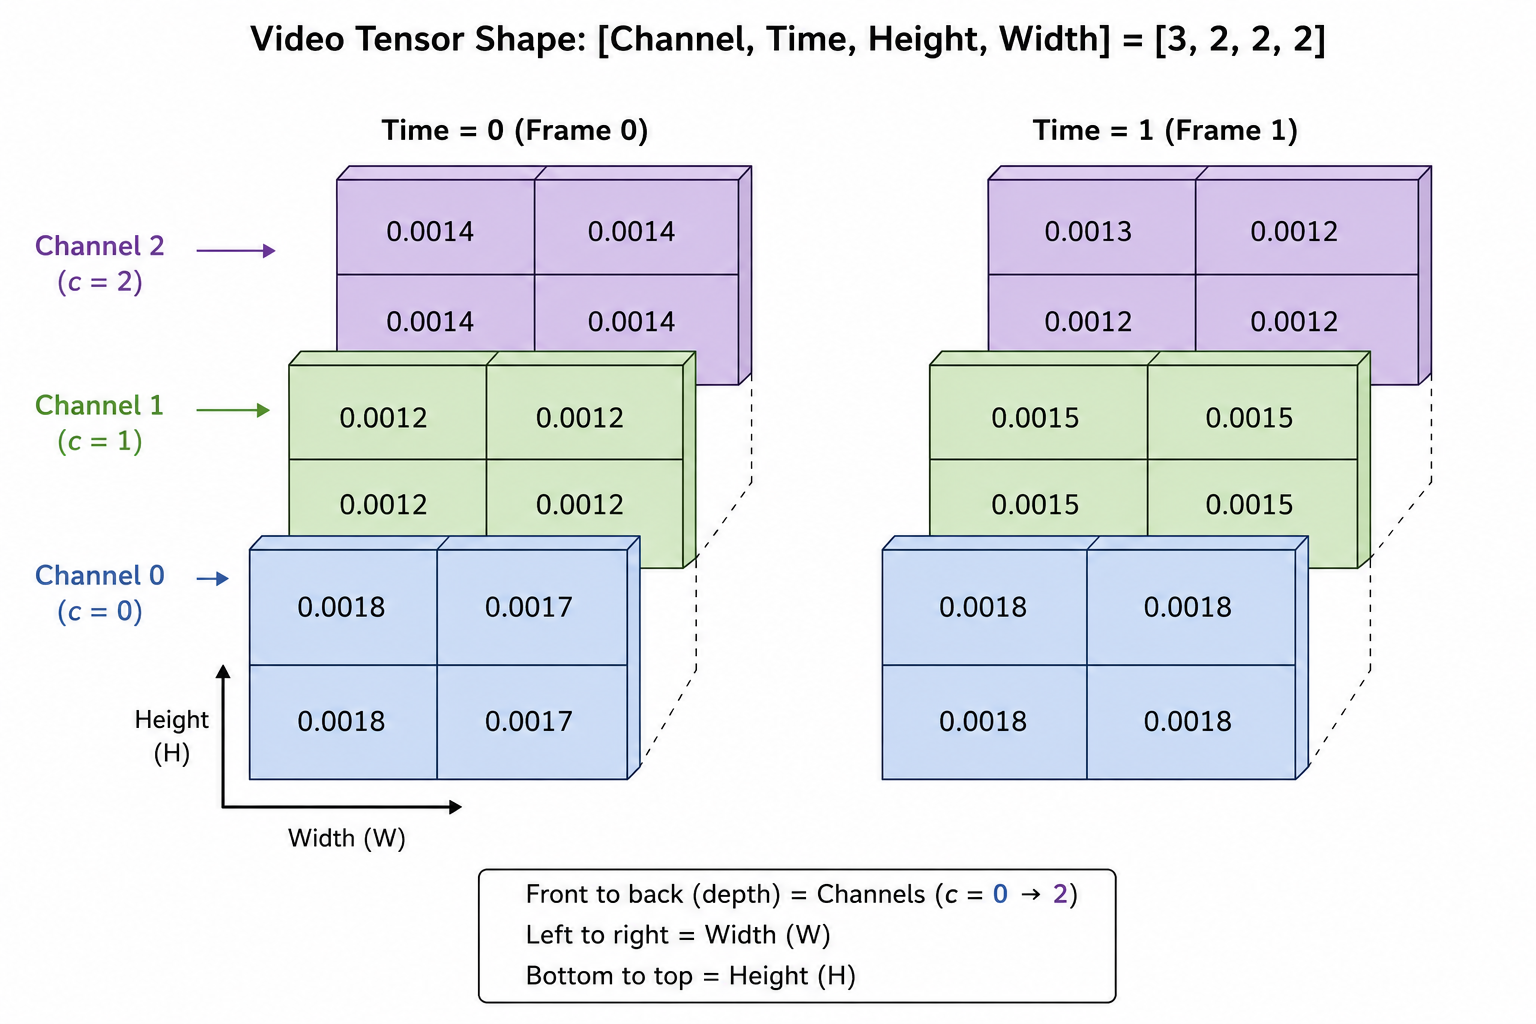

In [ ]:
# Functional Resize and Cast to avoid rigid dimensional requirements
# Standardize the spatial resolution to 224x224 and cast to float32
video_tensor = F.resize(video_tensor, size=[224, 224])
video_tensor = video_tensor.to(torch.float32) / 255.0

print(f"Final video tensor peek:\n{video_tensor[:, 2:4, 20:22, 20:22]}")

# Construct the batch (here batch is 1 because we have single video)
batch_tensor = video_tensor.unsqueeze(0)

Final video tensor peek:
tensor([[[[2.7435e-08, 2.6015e-08],
          [2.7435e-08, 2.6252e-08]],

         [[1.8920e-08, 1.8447e-08],
          [1.7974e-08, 1.7974e-08]]],


        [[[2.8144e-08, 2.7198e-08],
          [2.7908e-08, 2.6962e-08]],

         [[2.3650e-08, 2.3177e-08],
          [2.2704e-08, 2.2704e-08]]],


        [[[2.2231e-08, 2.1285e-08],
          [2.1758e-08, 2.1285e-08]],

         [[1.9393e-08, 1.8920e-08],
          [1.8447e-08, 1.8447e-08]]]])


In [ ]:
# Load the tensor to GPU VRAM
gpu_video_batch = batch_tensor.to(device)

print(f"Final tensor shape in VRAM:\n{gpu_video_batch.shape}")
print(f"Final data type: {gpu_video_batch.dtype}")

Final tensor shape in VRAM:
torch.Size([1, 3, 16, 224, 224])
Final data type: torch.float32


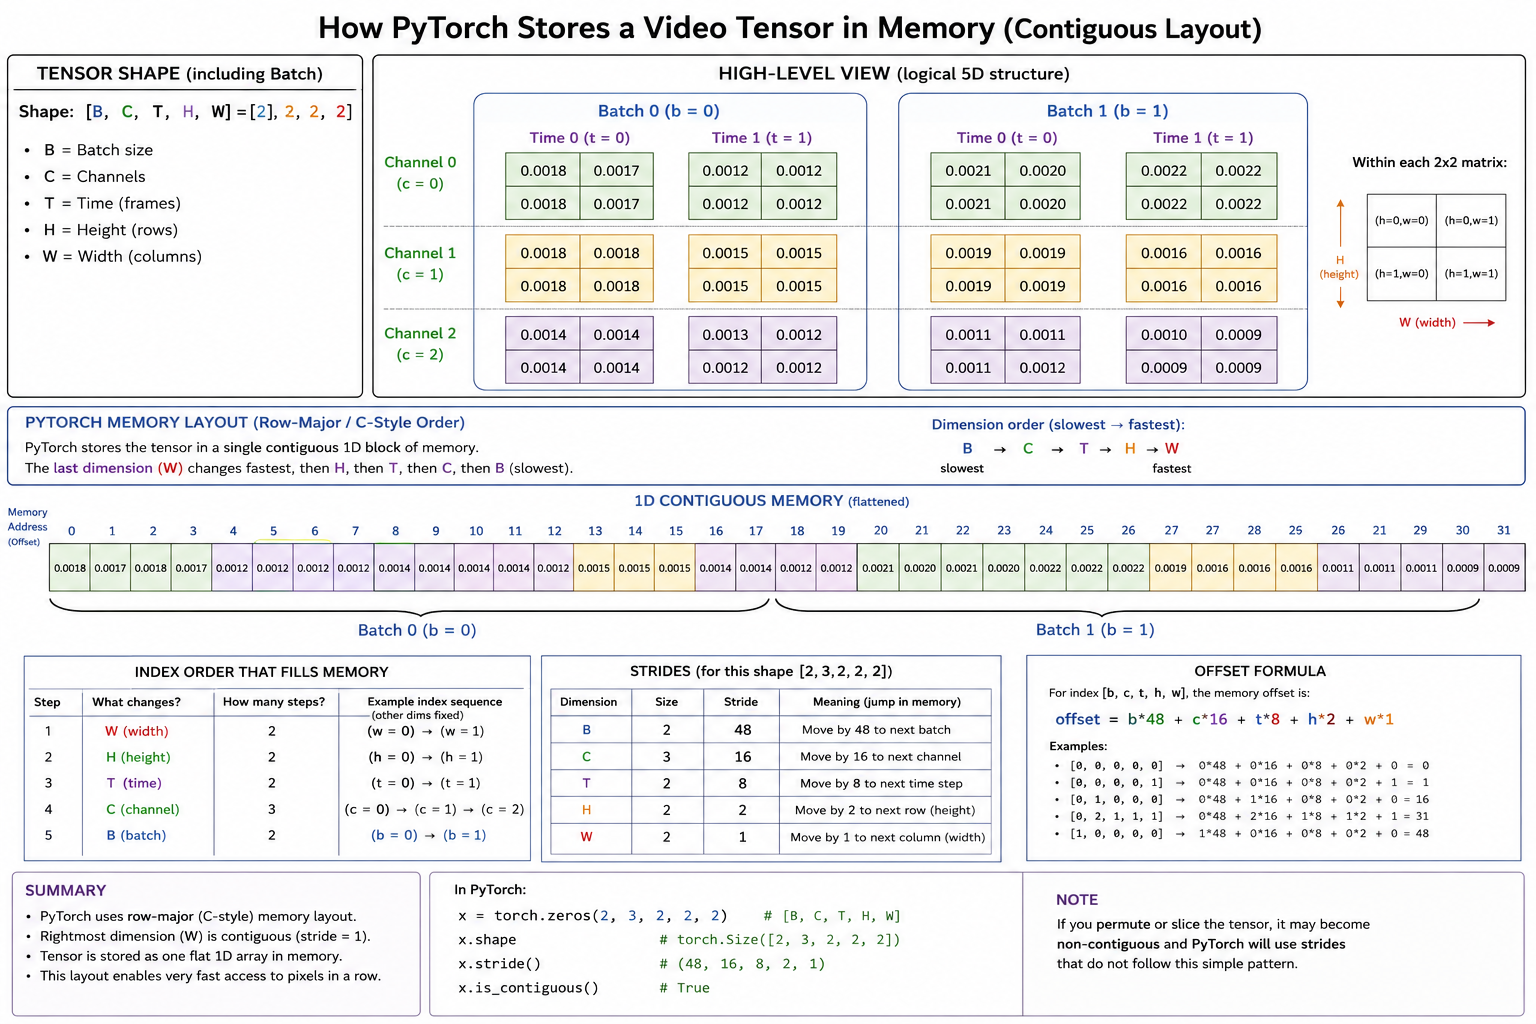

In [ ]:
# Instantiating a a spatiotemporal (3D Convolution) feature extractor
conv3d_layer = nn.Conv3d(
    in_channels=3,      # RGB channels as input
    out_channels=16,    # 16 feature maps with distinct motion/shape patterns extractions
    kernel_size=3,      # 3x3x3x3 spatiotemporal kernel block (3 channels deep, 3 frames across, 3 height, 3 width)
    stride=2,           # Jump 2 pixels spatially, jump 2 frames temporally
    padding=1           # 1 pixel zero-padding
).to(device)

# Execute forward pass
output_tensor = conv3d_layer(gpu_video_batch)

print("Execution and verification")
print(f"Output tensor shape: {output_tensor.shape}")

# Mathematical Verification: Output = floor((Input - Kernel + 2*Padding) / Stride) + 1
# Time: floor((16 - 3 + 2(1)) / 2) + 1 = 8
# Height/Width: floor((224 - 3 + 2(1)) / 2) + 1 = 112
print(f"Mathematical verification: [Batch:{output_tensor.shape[0]}, Channels:{output_tensor.shape[1]}, Time:{output_tensor.shape[2]}, Height:{output_tensor.shape[3]}, Width:{output_tensor.shape[4]}]")

Execution and verification
Output tensor shape: torch.Size([1, 16, 8, 112, 112])
Mathematical verification: [Batch:1, Channels:16, Time:8, Height:112, Width:112]


### Object Detection

#### How it Works:
Let's look at a strict scenario detailing exactly how a YOLO-style (You Only Look Once) architecture preserves spatial memory and formats its final output tensor to detect multiple objects.

**The Scenario: Autonomous Intersection Monitoring**
Our model needs to detect Cars and Bikes in a high-resolution $448 \times 448$ image. Let's trace the exact memory pipeline.

##### **1. The Input and The Encoder (Preserving the Grid)**
*   **The Input:** A batch of 1 RGB image. VRAM Shape: `[1, 3, 448, 448]`.
*   **The Execution:** The tensor passes through multiple `Conv2d` and `MaxPool2d` layers.
*   **The Difference:** In a Classifier (Chapter 4), we kept pooling until the spatial grid became $1 \times 1$. Here, the engineer explicitly stops the pooling operations when the spatial dimensions reach $7 \times 7$.
*   **The Output of Encoder:** `[1, 1024, 7, 7]`.
    *   *CS Concept:* We now have a $7 \times 7$ grid in VRAM. Mathematically, each of these 49 memory cells maps to a $64 \times 64$ pixel patch on the original $448 \times 448$ image ($448 / 7 = 64$).

##### **2. The Prediction Head (The 1x1 Convolution)**
We must convert the 1024 abstract feature channels into strict bounding box predictions. We do NOT use `nn.Flatten`. Instead, we use a `Conv2d` layer with a $1 \times 1$ kernel.
*   **The Goal:** Let's say we configure the network to predict exactly **2 bounding boxes** per grid cell, and we have **2 classes** (Car, Bike).
*   **The Math for Output Channels:**
    *   Box 1 requires 5 numbers: `[confidence, x, y, width, height]`
    *   Box 2 requires 5 numbers: `[confidence, x, y, width, height]`
    *   Class probabilities require 2 numbers: `[prob_car, prob_bike]`
    *   Total depth required per cell: $5 + 5 + 2 = \mathbf{12}$.
*   **The Execution:** A $1 \times 1$ Convolution maps the 1024 channels down to 12 channels without altering the spatial grid.
*   **The Final Tensor Output:** `[1, 12, 7, 7]`.

##### **3. Decoding the Dense Tensor (Memory Extraction)**
Let's look at exactly what is stored inside this final `[1, 12, 7, 7]` VRAM block.

Imagine a Car is physically located in the top-right corner of the original image. That physical location maps to row `0`, column `6` of our $7 \times 7$ grid.

The CPU queries that specific memory address in the tensor: `output[0, :, 0, 6]`. It retrieves a 1D vector of 12 floating-point numbers:
`[0.85, 0.5, 0.5, 0.4, 0.2, 0.12, 0.8, 0.9, 0.6, 0.7, 0.95, 0.05]`

**How the Software parses this vector:**
*   **Box 1 Data:** `[0.85, 0.5, 0.5, 0.4, 0.2]`
    *   `0.85` ($p_c$): The network is 85% confident an object is here.
    *   `0.5, 0.5` ($x, y$): The center of the object is exactly in the middle of this specific grid cell.
    *   `0.4, 0.2` ($w, h$): The object's width is 40% of the entire image, and its height is 20%.
*   **Box 2 Data:** `[0.12, 0.8, 0.9, 0.6, 0.7]`
    *   `0.12` ($p_c$): Only 12% confident. (The CPU will discard this box later).
*   **Class Probabilities:** `[0.95, 0.05]`
    *   `0.95`: 95% probability the object is a Car.
    *   `0.05`: 5% probability the object is a Bike.

##### **4. The Post-Processing Filter (NMS)**
The network outputted a dense tensor containing $49 \times 2 = 98$ total bounding boxes (2 boxes for every cell in the $7 \times 7$ grid).

The CPU executes the **Non-Maximum Suppression (NMS)** algorithm.
1. It deletes all boxes where the $p_c$ (confidence) is less than `0.5`. (Usually dropping ~90 of them instantly).
2. It calculates the **Intersection over Union (IoU)** of the remaining boxes.
3. If two boxes heavily overlap (IoU > `0.5`) and predict the same class, it deletes the one with the lower confidence score.
4. The final result is a clean JSON array of perhaps 3 precise bounding boxes, which the software then draws onto the screen.


[YOLO Overview](https://www.youtube.com/watch?v=svn9-xV7wjk&t=238s)

#### MiniYOLO (end-to-end YOLO simulation)
_Just an example framework to understand the internal working and base architecture_

##### Imports

In [ ]:
import torch
import torch.nn as nn

##### GPU Setup

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Current device is: {device}")

Current device is: cuda


##### CNN Architecture (YOLO)

In [ ]:
# Model class
class MiniYOLO(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder (preserving the sptial grid)
        # We agressively pool the 448x448 image exactl 6 times till it is 7x7 (448/2^6 = 448/64 = 7)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.MaxPool2d(2, stride=2),          # output: 224x224
            nn.Conv2d(16, 32, 3, padding=1), nn.MaxPool2d(2, stride=2),         # output: 112x112
            nn.Conv2d(32, 64, 3, padding=1), nn.MaxPool2d(2, stride=2),         # output: 56x56
            nn.Conv2d(64, 128, 3, padding=1), nn.MaxPool2d(2, stride=2),        # output: 28x28
            nn.Conv2d(128, 256, 3, padding=1), nn.MaxPool2d(2, stride=2),       # output: 14x14
            nn.Conv2d(256, 1024, 3, padding=1), nn.MaxPool2d(2, stride=2),      # output: 7x7
        )

        # Prediction head (1x1 kernel convolution)
        # 2 boxes per cell and each box has 5 values (pc, x_center, y_center, widht, height) and 2 classes (car/bike)
        # Depth = (2*5) + 2 = 12 output channels
        self.head = nn.Conv2d(1024, 12, 1)

        # We apply a sigmoid activation to constrain the confidence strictly between 0.0 and 1.0
        self.activation = nn.Sigmoid()


    def forward(self, x):
        features = self.encoder(x)
        raw_predictions = self.head(features)
        predictions = self.activation(raw_predictions)

        return predictions

##### Intersection over Union Operation

In [ ]:
# Calculates the mathematical overlap of the two bounding boxes
# Boxes are in format: [x_center, y_center, width, height]
def calculate_iou(box1, box2):
    # Convert [center, width, height] to [x1, y1, x2, y2] for corners
    # Box 1
    b1_x1, b1_x2 = box1[0] - box1[2]/2, box1[0] + box1[2]/2
    b1_y1, b1_y2 = box1[1] - box1[3]/2, box1[1] + box1[3]/2
    # Box 2
    b2_x1, b2_x2 = box2[0] - box2[2]/2, box2[0] + box2[2]/2
    b2_y1, b2_y2 = box2[1] - box2[3]/2, box2[1] + box2[3]/2

    # Find the coordinates of the intersecting rectangle
    inter_x1 = max(b1_x1, b2_x1)
    inter_x2 = max(b1_x2, b2_x2)
    inter_y1 = max(b1_y1, b2_y1)
    inter_y2 = max(b1_y2, b2_y2)

    # Calculate the area of INTERSECTION (if they don't overlap, area is 0)
    inter_width = max(0, inter_x2 - inter_x1)
    inter_height = max(0, inter_y2 - inter_y1)
    intersection_area = inter_width * inter_height

    # Calculate the area of UNION
    b1_area = (b1_x2 - b1_x1) * (b1_y2 - b1_y1)
    b2_area = (b2_x2 - b2_x1) * (b2_y2 - b2_y1)
    union_area = b1_area + b2_area - intersection_area

    # Return the IoU ratio
    # Add le-6 (epsilon) to the denominator to prevent mathematically Division by 0 error
    return intersection_area / (union_area + 1e-6)

##### Non-Maximum Supression (NMS)

###### **The Problem: The Over-Eager Network**
When a model like YOLO looks at a picture of a single car, it doesn't just draw one bounding box. Because of the sliding window and grid system, multiple cells right next to each other might all detect the exact same car.

The network will output a messy cluster of 15 overlapping bounding boxes around the exact same car.
We only want **one** box per object. We need an algorithmic filter to clean up the mess. That filter is NMS.

*(Note: NMS is not a Neural Network layer. It is a standard Python `while` loop executed by the CPU immediately after the GPU finishes its predictions).*

</br>

##### **The NMS Algorithm (Step-by-Step)**

Imagine you have a list of 100 raw bounding boxes outputted by the network.

**Step 1: The Trash Filter (Confidence Thresholding)**
Every predicted box comes with an "Objectness Confidence" score (e.g., `0.99`, `0.45`, `0.02`).
*   **The Action:** The CPU loops through the list and instantly deletes any box with a confidence score below a certain threshold (e.g., `0.50`).
*   **The Result:** We throw away 80 boxes that the network was mostly guessing on. We have 20 decent boxes left.

**Step 2: The Sorting Phase**
*   **The Action:** The CPU takes the 20 surviving boxes and sorts them in a line from Highest Confidence to Lowest Confidence.
*   **Example Lineup:** `[Box A (95%), Box B (90%), Box C (85%), Box D (12%)]`

**Step 3: The "King of the Hill" Selection**
*   **The Action:** We look at the very front of the line. We take the box with the absolute highest confidence (Box A at 95%).
*   **The Rule:** Because it has the highest score, we trust it the most. We permanently save Box A to our final "True Detections" list.

**Step 4: The "Suppression" (Using IoU)**
Now we must find out if the other boxes in line are just duplicates of Box A.
*   **The Action:** We use the **IoU** math we just learned. We compare the overlap of our winning Box A against Box B, then Box A against Box C, and so on.
*   **The Rule:** If a box overlaps heavily with Box A (e.g., their IoU is greater than `0.4`), the computer says: *"Ah, Box B is pointing to the exact same car as Box A. But Box A is 95% confident, and Box B is only 90%. Box B is a duplicate."*
*   **The Deletion:** Box B is permanently deleted (Suppressed) from RAM. It is *Not the Maximum*, so it is *Suppressed*.

**Step 5: Repeat for the Next Object**
*   **The Action:** We look back at our line. Box A is saved. Box B and C were deleted because they overlapped Box A.
*   The next box remaining in line might be pointing to a completely different object (like a Bicycle on the other side of the image).
*   We make that Bicycle box the new "King of the Hill," save it to our True Detections list, and check the remaining line to delete *its* duplicates.
*   The loop repeats until the line is completely empty.

</br>

###### **Summary**
NMS is just a smart sorting loop. It grabs the highest-scoring box, deletes all neighboring boxes that overlap it, and then moves on to the next highest-scoring box. It transforms a messy cloud of 100 predictions into 3 clean, perfect bounding boxes ready to be drawn on the screen.

In [ ]:
# Filters the raw dense output into a clean list of true detections
# prediction_list: List of [pc, x_center, y_center, width, height, class_id]
def non_maximum_supression(prediction_list, conf_threshold=0.5, iou_threshold=0.4):

    # Filter out all boxes where the Object Confidence (pc) is below threshold
    boxes = []
    for box in prediction_list:
        if box[0] > conf_threshold:
            boxes.append(box)

    # Sort remaining boxes by Confidence (Highest First)
    boxes = sorted(boxes, key=lambda x: x[0], reverse=True)

    # The Elimination loop
    true_detections = []
    while boxes:
        # Pop the box with the highest confidence and save it as a "True" detection
        best_box = boxes.pop(0)
        true_detections.append(best_box)

        remaining_boxes = []
        for other_box in boxes:
            # If they predict the same class and their IoU overlap is too high, it's a duplicate
            # We drop it, otherwise we keep it in the remaining_boxes list
            if best_box[5] == other_box[5] and calculate_iou(best_box[1:5], other_box[1:5]) > iou_threshold:
                continue
            remaining_boxes.append(other_box)

        # Update the list for next for loop iteration
        boxes = remaining_boxes

    return true_detections


##### The Simulation

In [ ]:
print("Initializing model and pushing a placeholder image")

# Instantiate our MiniYOLO model with random weights in memory
model = MiniYOLO()

# Create a dummy image
dummy_image = torch.randn(1, 3, 448, 448)

# Execute the forward pass (inference only coz we are not training the network just predicting the object)
with torch.no_grad():
    raw_output = model(dummy_image)

print(f"Raw output Tensor Shape: {raw_output.shape} | Exptected {1, 12, 7, 7}")

print("\n Simulating a Network Detection")
# Because this is just a simulation and the network is not trained, it outputs random noise
# To test our NMS, we wil manually intect two mathematically overlapping predictions
# Into the center grid cell Row 3 Col 3

# Memory layout: [pc, x, y, w, h]
# Injection 1: 95% confident there is a car in the center
raw_output[0, 0:5, 3, 3] = torch.tensor([0.95, 0.5, 0.5, 0.4, 0.2])
# Injection 2: 80% confident there is a car in the almost exact same spot (duplicate)
raw_output[0, 5:10, 3, 3] = torch.tensor([0.80, 0.51, 0.49, 0.41, 0.22])
# Set class probabilites to car (class 0: 1.0, class 1: 0.0)
raw_output[0, 10:12, 3, 3] = torch.tensor([1.0, 0.0])

print("Artificially injected two overlapping Car predictions into cell [3, 3]")
print("\n Decoding the dense tensor")

parsed_prediction_list = []

# Loop over the 7x7 spatial grid
for row in range(7):
    for col in range(7):
        # Extract the 12 values for this specific cell
        cell_data = raw_output[0, :, row, col]
        # Extract Box 1 and Box 2 [pc, x, y, w, h]
        box1 = cell_data[0:5].tolist()
        box2 = cell_data[5:10].tolist()
        # Determine the class probabilities (argmax of the last 2 values)
        class_probs = cell_data[10:12]
        class_id = torch.argmax(class_probs).item()
        # Append to our parsed prediction list: [pc, x, y, w, h]
        parsed_prediction_list.append(box1 + [class_id])
        parsed_prediction_list.append(box2 + [class_id])

print(f"Total raw bounding boxes extracted: {len(parsed_prediction_list)} (7 * 7 * 2 = 98)")
print("\n Executing Non Maximum Supression (NMS):")

# We pass all 98 boxes into our NMS algorithm
final_detections = non_maximum_supression(parsed_prediction_list, conf_threshold=0.5, iou_threshold=0.4)

print("\nFinal Output")
print(f"Total valid objects detected: {len(final_detections)}")
for i, det in enumerate(final_detections):
    # Final Detection Mem Layout: [pc, x, y, w, h, class]
    print(f"Detection: {i+1}")
    print(f"    Class: {"Car" if det[5] == 0 else "Bike"}")
    print(f"    Confidence: {det[0]*100:.2f}%")
    print(f"    Coordinates: [X: {det[1]:.2f}, Y: {det[2]:.2f}, W: {det[3]:.2f}, H: {det[4]:.2f}]")


Initializing model and pushing a placeholder image
Raw output Tensor Shape: torch.Size([1, 12, 7, 7]) | Exptected (1, 12, 7, 7)

 Simulating a Network Detection
Artificially injected two overlapping Car predictions into cell [3, 3]

 Decoding the dense tensor
Total raw bounding boxes extracted: 98 (7 * 7 * 2 = 98)

 Executing Non Maximum Supression (NMS):

Final Output
Total valid objects detected: 1
Detection: 1
    Class: Car
    Confidence: 95.00%
    Coordinates: [X: 0.50, Y: 0.50, W: 0.40, H: 0.20]


### End to End production level CNN pipeline for a Toll Booth API
#### It classifies vehicles and detects it's number plates

##### Dataset Download and Setup

In [ ]:
# Fetch Kaggle secrets and set them in os enviroment
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

In [ ]:
# Download the kaggle dataset
!kaggle datasets download -d andrewmvd/car-plate-detection

In [ ]:
# Unzip the dataset into a directory named "toll_booth_dataset"
!unzip -q car-plate-detection.zip -d toll_booth_dataset/

##### Imports

In [2]:
import os
import xml.etree.ElementTree as ET
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as F
import torch.nn as nn
import torchvision.models as models

##### GPU Setup

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Available device: {device}")

Available device: cuda


##### Data Pipeline

In [4]:
# Extract images and XML bounding box data from the secondary storage (SSD) and format them into strict PyTorch tensors
class TollBoothDataset(Dataset):

    # Dataset constructor
    def __init__(self, root_dir, image_size=224):
        self.image_dir = os.path.join(root_dir, "images")
        self.annot_dir = os.path.join(root_dir, "annotations")
        self.image_size = image_size

        # Create a list of image filenames
        self.image_files = []
        for f in os.listdir(self.image_dir):
            if f.endswith(".png"):
                self.image_files.append(f)

    # Override the __len__ method to return the length of the self.image_files
    def __len__(self):
        return len(self.image_files)

    # The dunder method that overrides the method of accessing of images with image_files[i] with custom method
    # We are doing some image processing here to prepare the image before feeding the model
    def __getitem__(self, idx):
        ## STEP 1: Disk I/O (read the image)
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        # Read with OpenCV, Swap BGR to RGB
        raw_image = cv2.imread(img_path)
        raw_iamge = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
        # Original dimensions are required to mathematically scale the bounding box
        org_h, org_w, _ = raw_image.shape

        ## STEP 2: DISK I/O (parse XML annotation for the image)
        xml_name = img_name.replace(".png", ".xml")
        xml_path = os.path.join(self.annot_dir, xml_name)
        # Parse the XML
        tree = ET.parse(xml_path)
        root = tree.getroot()
        # Extract the first bounding box (xmin, ymin, xmax, ymax)
        bndbox = root.find("object").find("bndbox")
        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)

        ## STEP 3: Geometric Normalization
        # Convert absolute pixel coordinates to relative floats [0.0, 1.0]
        # Calculate Center X, Center Y, Width and Height
        x_center = ((xmin + xmax) / 2.0) / org_w
        y_center = ((ymin + ymax) / 2.0) / org_h
        width = (xmax - xmin) / org_w
        height = (ymax - ymin) / org_h
        # The final geometry of the box tensor
        box_tensor = torch.tensor([x_center, y_center, width, height], dtype=torch.float32)

        ## STEP 4: Simulate Classification Label
        # In a real multi-task dataset this would be read from an XML
        # We simulate a class ID (0 = Car, 1 = Truck)
        vehicle_class = torch.tensor(torch.randint(0, 2, (1, )).item(), dtype=torch.long)

        ## STEP 5: Image Preprocessing (applying standard image transforms)
        # Cast to tensor [C, H, W], resize to 224x224, scale to [0.0, 1.0]
        image_tensor = torch.from_numpy(raw_image).permute(2, 0, 1)
        image_tensor = F.resize(image_tensor, size=[self.image_size, self.image_size])
        image_tensor = image_tensor.to(torch.float32) / 255.0

        return image_tensor, vehicle_class, box_tensor

In [5]:
# Instantiate the data pipeline
dataset = TollBoothDataset(root_dir="toll_booth_dataset")
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)

FileNotFoundError: [Errno 2] No such file or directory: 'toll_booth_dataset/images'

##### Dual-Head Architecture Class (for classification and object detection)

In [14]:
# This is a Multi-Task Neutral Network
# Extracts geometric features once then mathematically splits the data to perform two distinct software tasks simultaneously
class TollBoothModel(nn.Module):

    # TollBoothModel constructor
    def __init__(self):
        super().__init__()

        ## The feature plane (feature extraction and encoding)
        # Download pre-trained ResNet-18 weights
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Freeze the weights (Disable autograd for the 11 million convolutions)
        for param in resnet.parameters():
            param.requires_grad = False
        # Isolate the Encoder: We strip away ResNet's original Classifier Head
        # list (resnet.children())[:-2] extracts all layers EXCEPT the last two (avgpool and fc)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        # The flattening bridge
        # The backbone outputs [Batch, 512, 7, 7]. We crush the spatial grid to 1x1 then flatten
        self.pool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
        self.flatten = nn.Flatten()

        ## The task plane (the split heads)
        # After flattening our memory shape is exactly [Batch, 512]
        # Head A: The vehicle classifier
        # Goal: Output raw logits for 2 classes (Car, Truck)
        self.classifier_head = nn.Sequential(
            nn.Linear(in_features=512, out_features=128),
            nn.ReLU(),
            nn.Linear(128, out_features=2)
        )
        # Head B: The license plate detector (bounding box regressor)
        # Goal: Output 4 geometric floats [x_center, y_center, width, height]
        self.detector_head = nn.Sequential(
            nn.Linear(in_features=512, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=4),
            # Sigmoid to force the output between 0.0 to 1.0
            # This perfectly matches our normalized ground truth labels
            nn.Sigmoid()
        )

    # The forward pass definition
    def forward(self, x):

        # Feature extraction (shared compute)
        features = self.backbone(x)         # VRAM Shape: [Batch, 512, 7, 7]
        features = self.pool(features)      # VRAM Shape: [Batch, 512, 1, 1]
        features = self.flatten(features)   # VRAM Shape: [Batch, 512]

        # Memory branching (parallel task execution)
        # We feed exact same 512 semantic features into BOTH heads
        class_logits = self.classifier_head(features)
        box_coordinates = self.detector_head(features)

        return class_logits, box_coordinates

In [15]:
# Instantiate the model
model = TollBoothModel().to(device)
print(f"Model instantiated with default weights:\n{model}")

# Shape verification
# Simulating batch of 16 images
dummy_batch = torch.randn(16, 3, 224, 224).to(device)

# Execute the Forward Pass
out_classes, out_boxes = model(dummy_batch)
print(f"\nOutput Memory States")
print(f"Classification Tensor Shape: {out_classes} | Expected: [16, 2]")
print(f"Detection Tensor Shape:      {out_boxes} | Expected: [16, 4]")

# Inspect the math of a single detection output
print(f"\nSample Bounding Box")
print(f"[X: {out_boxes[0][0]:.3f}, Y: {out_boxes[0][1]:.3f}, W: {out_boxes[0][2]:.3f}, H: {out_boxes[0][3]:.3f}]");

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Model instantiated with default weights:
TollBoothModel(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, mom